# Agent Memory in Neo4j

**Bi-temporal facts, incremental write-back, and the read path that runs on every turn.**

[Notebook 02](02_neo4j_graphrag_retrieval.ipynb) took the business-news graph from JSON to a queryable
database and stopped there. It loaded one of the two graphs [notebook 01](01_gliner25_knowledge_graphs.ipynb)
built and skipped the other, with a one-line note that the memory graph "needs the temporal layer to survive
the trip". This notebook is that trip.

The memory graph is the harder problem, and the difficulty is not the extraction. It is that a memory graph is
**incremental** (episodes arrive one at a time and must be linked to what is already stored), **mutable**
(a fact asserted in February can be false by May, and the graph has to know), and **hot** (it is read into a
prompt on every single turn, so the read path is a latency budget rather than an analytics query).

Six things, in order:

1. What actually differs between the two corpora, measured rather than asserted.
2. A property-graph model for bi-temporal facts — two encodings, benchmarked, one chosen.
3. "What does it believe now" and "what did it believe in March" as different Cypher over the same data.
4. Write-back: a held-out session extracted and resolved **against the live graph**, superseding a fact in
   the database.
5. Prompt assembly, timed. Three strategies, one of them ten times slower than another.
6. Where the model stops working, with the index plans and a scaling curve to say at what size.

### One database, two graphs

Neo4j Community gives you a single database, and the instance this notebook talks to already holds notebook
02's business-news graph. Nothing here disturbs it: every label written by this notebook is prefixed `Mem`
and carries a shared `__Memory__` label, the two graphs coexist, and §7 tears the memory namespace back down
and verifies the business-news graph comes back with the counts, labels, relationship types, and search
indexes it started with. Both halves of that are checked in-notebook.

## 0. Setup

In [1]:
import os, sys, time, json, statistics, warnings
from dataclasses import replace
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 44)

import neo4j, kgx
from kgx.graph import KnowledgeGraph
from kgx.temporal import TemporalGraph, Fact, graph_alternatives, SUPERSEDING_RELATIONS
from kgx.data.documents import DOCUMENTS
from kgx.data.conversations import SESSIONS, GOLD_MEMORY_FACTS, CONTRADICTIONS
from kgx.coref import USER_CANON_ID
from kgx.neo4j_io import Neo4jConfig, connect, counts, ENTITY_LABEL
import kgx.memory_neo4j as mn

print(f"kgx {kgx.__version__}   neo4j driver {neo4j.__version__}")
print(f"corpus     {len(SESSIONS)} sessions, {sum(len(s['turns']) for s in SESSIONS)} turns, "
      f"{sum(len(t['text'].split()) for s in SESSIONS for t in s['turns'])} words")
print(f"ontology   {len(kgx.AGENT_MEMORY.entities)} entity types, {len(kgx.AGENT_MEMORY.relations)} relations")
print(f"gold       {len(GOLD_MEMORY_FACTS)} memory facts, {len(CONTRADICTIONS)} known contradictions")

kgx 0.1.0   neo4j driver 6.2.0
corpus     5 sessions, 80 turns, 2031 words
ontology   13 entity types, 16 relations
gold       36 memory facts, 2 known contradictions


In [2]:
config = Neo4jConfig.from_env(
    uri=os.environ.get("NEO4J_URI", "bolt://localhost:7690"),
    user=os.environ.get("NEO4J_USER", "neo4j"),
    password=os.environ.get("NEO4J_PASSWORD", "sandbox-kg"),
)
if "driver" in globals():
    driver.close()
driver = connect(config, notifications="OFF")

records, _, _ = driver.execute_query(
    "CALL dbms.components() YIELD name, versions, edition RETURN versions[0] AS v, edition")
print(f"connected to {config.uri} — Neo4j {records[0]['v']} ({records[0]['edition']})")

# A previous run that died mid-notebook leaves the memory namespace behind, and counting
# it into the baseline would make §7's restoration check fail on a database that is clean.
leftover = mn.teardown(driver)
if leftover["nodes_deleted"] or leftover["indexes_dropped"]:
    print(f"cleared a previous run's memory namespace: {leftover}")

# What is already here. This notebook must give it back unchanged.
BASELINE = counts(driver)
records, _, _ = driver.execute_query(
    "SHOW INDEXES YIELD name, type WHERE type IN ['VECTOR','FULLTEXT'] RETURN name ORDER BY name")
BASELINE_INDEXES = [r["name"] for r in records]
print(f"already in the database: {BASELINE['nodes']} nodes, {BASELINE['relationships']} relationships")
print(f"  labels        {BASELINE['by_label']}")
print(f"  search indexes {BASELINE_INDEXES}")

connected to bolt://localhost:7690 — Neo4j 5.26.19 (community)
already in the database: 119 nodes, 241 relationships
  labels        {'__Entity__': 109, 'Geography': 23, 'FinancialMetric': 19, 'Product': 10, 'Document': 10, 'BusinessSegment': 9, 'Company': 7, 'Security': 7, 'BusinessEvent': 7, 'Person': 7, 'Sector': 6, 'RiskFactor': 6, 'Regulator': 5, 'Commodity': 3}
  search indexes ['document_ft', 'document_vec', 'entity_ft', 'entity_vec']


## 1. Why this is not the same problem as notebook 02

Both graphs came out of the same extractor and the same five-stage pipeline. They are close in size — a
couple of thousand words each, a hundred-odd entities. That similarity is why it is worth being precise about
what actually differs, because it is not the extraction and it is not the scale.

The business-news corpus is **ten documents that arrived at once and will never change**. A press release
from 14 January says Northwind is acquiring Cascade; it will still say that in ten years. The graph is a
statement about a fixed set of texts, and re-running the loader over the same texts produces the same graph.
Notebook 02's `load_graph` is idempotent for exactly that reason and never has to consider whether a new
document *invalidates* an old one.

The conversation corpus is **five sessions spread over four months, still arriving**. Session 4 contains the
sentence *"honestly I was wrong about npm — I've switched to pnpm"*. Both `prefers npm` and `prefers pnpm` are
extracted, both are correct readings of their own text, and exactly one of them should reach the model's
context window on the next turn.

In [3]:
from datetime import datetime

bn = KnowledgeGraph.from_json(ROOT / "output" / "business_news_kg.json", kgx.BUSINESS_NEWS)
am = KnowledgeGraph.from_json(ROOT / "output" / "agent_memory_kg.json", kgx.AGENT_MEMORY)

span = (datetime.fromisoformat(SESSIONS[-1]["timestamp"].replace("Z", "+00:00"))
        - datetime.fromisoformat(SESSIONS[0]["timestamp"].replace("Z", "+00:00"))).days

contrast = pd.DataFrame([
    {"": "source units",        "business news (nb 02)": f"{len(DOCUMENTS)} documents",
     "agent memory (here)": f"{len(SESSIONS)} sessions / {sum(len(s['turns']) for s in SESSIONS)} turns"},
    {"": "words",               "business news (nb 02)": sum(len(d["text"].split()) for d in DOCUMENTS),
     "agent memory (here)": sum(len(t["text"].split()) for s in SESSIONS for t in s["turns"])},
    {"": "arrival",             "business news (nb 02)": "one batch",
     "agent memory (here)": f"incremental, over {span} days"},
    {"": "canonical entities",  "business news (nb 02)": len(bn.entities),
     "agent memory (here)": len(am.entities)},
    {"": "edges",               "business news (nb 02)": len(bn.edges),
     "agent memory (here)": len(am.edges)},
    {"": "edges witnessed by >1 source",
     "business news (nb 02)": sum(1 for e in bn.edges if len({ev.doc_id for ev in e.evidence}) > 1),
     "agent memory (here)": sum(1 for e in am.edges
                                if len({ev.doc_id.split(":")[0] for ev in e.evidence}) > 1)},
    {"": "read pattern",        "business news (nb 02)": "on demand, per question",
     "agent memory (here)": "every turn, before the model runs"},
]).set_index("")
display(contrast)

,business news (nb 02),agent memory (here)
,,
source units,10 documents,5 sessions / 80 turns
words,2284,2031
arrival,one batch,"incremental, over 128 days"
canonical entities,109,219
edges,68,123
edges witnessed by >1 source,7,10
read pattern,"on demand, per question","every turn, before the model runs"


Nothing in that table forces a different database design. The next one does.

`kgx.temporal.TemporalGraph` is an append-only fact log that supersedes rather than deletes. Run it over both
graphs, one episode at a time in date order, and count how many facts stop being true.

In [4]:
import collections

def facts_by_episode(graph, episode_of, timestamps):
    """One Fact per (edge, episode-that-witnessed-it), oldest first.

    The stored graphs are already merged across their whole corpus, so an edge
    carries evidence from several documents at once. Splitting that evidence back
    out by source recovers the arrival order without re-running extraction --
    supersession is order-dependent by construction, so the order has to be real.
    """
    out = []
    for edge in graph.edges:
        by_ep = collections.defaultdict(list)
        for ev in edge.evidence:
            by_ep[episode_of(ev.doc_id)].append(ev)
        for episode, evs in by_ep.items():
            head, tail = graph.entities.get(edge.head), graph.entities.get(edge.tail)
            if head is None or tail is None or episode not in timestamps:
                continue
            out.append(Fact(
                head=edge.head, relation=edge.type, tail=edge.tail,
                head_name=head.canonical, tail_name=tail.canonical, tail_type=tail.type,
                confidence=max(ev.confidence for ev in evs), support=len(evs),
                episode_id=episode, valid_from=timestamps[episode], recorded_at=timestamps[episode],
                evidence=[ev.snippet for ev in sorted(evs, key=lambda v: -v.confidence)[:2]],
            ))
    return sorted(out, key=lambda f: (f.valid_from, -f.confidence))

DOC_DATES = {d["doc_id"]: d["date"] + "T00:00:00Z" for d in DOCUMENTS}
SESSION_TS = {s["session_id"]: s["timestamp"] for s in SESSIONS}

rows = []
for label, graph, episode_of, stamps in [
    ("business news", bn, lambda d: d, DOC_DATES),
    ("agent memory", am, lambda d: d.split(":")[0], SESSION_TS),
]:
    log = TemporalGraph(alternative_fn=graph_alternatives(graph, min_confidence=0.6))
    for fact in facts_by_episode(graph, episode_of, stamps):
        log.assert_fact(fact)
    rows.append({"corpus": label, "episodes": len(stamps), "facts asserted": len(log.facts),
                 "still current": len(log.current()),
                 "superseded": len(log.facts) - len(log.current())})
    if label == "agent memory":
        memory_log = log
    else:
        news_log = log
display(pd.DataFrame(rows).set_index("corpus"))

for label, log in [("business news", news_log), ("agent memory", memory_log)]:
    print(f"\n{label} — what changed:")
    for old, new in log.contradictions():
        print(f"   {old.head_name} {old.relation}: {old.tail_name!r} ({old.episode_id})"
              f" -> {new.tail_name!r} ({new.episode_id})")

,episodes,facts asserted,still current,superseded
corpus,,,,
business news,10,69,67,2
agent memory,5,126,118,8



business news — what changed:
   Marcus Webb officer_of: 'Northwind Logistics Inc' (d01) -> 'Vantage Energy Partners' (d08)
   Marcus Webb officer_of: 'Vantage Energy Partners' (d08) -> 'Northwind Logistics Inc' (d09)

agent memory — what changed:
   Priya Raman uses_tool: 'npm' (s1) -> 'pnpm' (s4)
   Priya Raman works_at: 'Northwind Logistics' (s1) -> 'CFO' (s3)
   Priya Raman prefers: 'pnpm' (s1) -> 'npm' (s2)
   Priya Raman prefers: 'npm' (s2) -> 'pnpm' (s4)
   Priya Raman works_at: 'CFO' (s3) -> 'Northwind Logistics' (s4)
   Priya Raman works_at: 'Northwind Logistics' (s4) -> 'us' (s4)
   Priya Raman works_at: 'us' (s4) -> 'Northwind Logistics' (s5)
   Priya Raman works_at: 'Northwind Logistics' (s5) -> 'dev' (s5)


Four times as many superseded facts, and the two lists are qualitatively different.

The news corpus produces two, and they are the same person appearing as an officer of two companies in
different filings. `officer_of` is marked `single` in `kgx.temporal.SUPERSEDING_RELATIONS`, so the temporal
layer reads the second filing as a job change. Whether it *is* one, or whether Marcus Webb simply holds two
board seats, is not decidable from the text. Notice what notebook 02 did with that: it loaded both edges,
side by side, and nothing broke — because nobody asks a news graph what is *currently* true. It is a record
of what was published.

That table is a separate editorial decision from the ontology, and worth knowing where to find, because the
ontology has a flag that looks like it does the same job and does not. `unique_head` constrains what the
*decoder* is allowed to emit; `SUPERSEDING_RELATIONS` decides what a new assertion closes. Neither
`kgx.temporal` nor `kgx.memory_neo4j` reads `unique_head` at all. The two agree on `officer_of` and disagree
on `works_at`, which is `single` here and carries no `unique_head`.

The memory list contains `prefers: npm → pnpm`, which is a real change of mind, correctly dated, and the
single most important fact in the graph for the next turn. It also contains `works_at` oscillating between an
employer and a job title, which is an extraction error arriving in the temporal layer wearing a
contradiction's clothes — notebook 01 §13 diagnosed that one and it is still here.

It also contains a third row that is neither: `prefers: pnpm (s1) → npm (s2)`. Session 1 says *"keep all the
JS tooling on npm — I know pnpm is what everyone's excited about but npm is what our CI knows"*, and the
extractor took the contrasted mention as the preference, while the real assertion reached the graph as
`uses_tool: npm`. The corpus answer key agrees — §4 prints it, and it has npm as the session-1 preference.
So the February belief the temporal layer is faithfully superseding was never held, and two of these three
rows are extraction errors the store can date but cannot doubt.

So: dropping the time dimension cost notebook 02 nothing measurable. Dropping it here means the assistant
recommends npm forever.

### The second difference: entities arrive with the episodes

Batch resolution sees every mention before it decides anything. Incremental resolution has to decide with only
the past available, and every episode is mostly *re-mentions* of things already known.

In [5]:
rows = []
for s in SESSIONS:
    sid = s["session_id"]
    mentioned = {e.canon_id for e in am.entities.values() if any(d.startswith(sid) for d in e.docs)}
    first_here = {e.canon_id for e in am.entities.values()
                  if min(d.split(":")[0] for d in e.docs) == sid}
    rows.append({"session": sid, "date": s["timestamp"][:10], "title": s["title"],
                 "entities mentioned": len(mentioned), "new": len(first_here),
                 "already known": len(mentioned) - len(first_here)})
growth = pd.DataFrame(rows).set_index("session")
display(growth)

print(f"by the last session, {growth['already known'].iloc[-1]}/{growth['entities mentioned'].iloc[-1]} "
      f"of the entities mentioned already existed.")
print("Every one of those is a lookup against the live graph that has to hit, or the memory forks.")

,date,title,entities mentioned,new,already known
session,,,,,
s1,2026-02-10,Order graph kickoff,59,59,0
s2,2026-03-04,Migration tooling and telemetry detour,57,51,6
s3,2026-04-15,Q2 review prep and the two blockers,48,44,4
s4,2026-05-20,Tooling switch and the workshop,39,27,12
s5,2026-06-18,Standardizing on Go,49,38,11


by the last session, 11/49 of the entities mentioned already existed.
Every one of those is a lookup against the live graph that has to hit, or the memory forks.


## 2. A property-graph model for bi-temporal facts

Two independent timelines, from `kgx.temporal`:

| | question it answers |
|---|---|
| `valid_from` / `valid_until` | when the fact was true **in the world** |
| `recorded_at` / `superseded_at` | when the system **learned** it, and when it learned otherwise |

They disagree constantly — an episode on 18 June can report something that was true from 1 April — and
collapsing them into one timestamp makes *"what did we believe last March?"* unanswerable, which is the
question you need on the day an agent acts on a fact that turns out wrong.

The property-graph question is where those four values live. There are two defensible answers and they are
worth building both, because the trade is usually argued and rarely measured.

### First, namespacing

The database already holds notebook 02's graph, which has a `Person` label and an `__Entity__` label. The
memory ontology also has a `person` type. Loading it as `:Person` would silently union two unrelated graphs
under one label, and every `MATCH (p:Person)` in either notebook would then be wrong. `kgx.memory_neo4j`
prefixes every ontology label with `Mem` and adds a shared `__Memory__` label instead of `__Entity__`.

In [6]:
print(f"ontology label -> node label")
for t in ("user", "person", "tool", "business_segment"):
    print(f"   {t:18} -> {mn.mem_label(t)}")
print(f"   shared secondary   -> {mn.MEMORY_LABEL}  (notebook 02 uses {ENTITY_LABEL})")

# The collision that prefixing avoids.
records, _, _ = driver.execute_query("MATCH (p:Person) RETURN count(*) AS n, collect(p.name)[..3] AS sample")
print(f"\n:Person already exists here — {records[0]['n']} nodes from the news graph: {records[0]['sample']}")
print("Priya Raman and Dev Shah will be :MemPerson, not :Person.")

ontology label -> node label
   user               -> MemUser
   person             -> MemPerson
   tool               -> MemTool
   business_segment   -> MemBusinessSegment
   shared secondary   -> __Memory__  (notebook 02 uses __Entity__)

:Person already exists here — 7 nodes from the news graph: ['Priya Raman', 'Marcus Webb', 'Elena Vasquez']
Priya Raman and Dev Shah will be :MemPerson, not :Person.


Prefixing makes coexistence safe for **label-scoped** queries, which is what both notebooks actually run. It
does nothing for a database-wide aggregate: `MATCH (n) RETURN count(n)` will see both graphs for the rest of
this notebook, and notebook 02's `counts(driver)` would report a total that includes memory nodes. That is a
real cost of one-database-per-instance and the reason §7 tears the namespace down again.

### Encoding A — validity as relationship properties

    (:MemUser)-[:PREFERS {valid_from, valid_until, recorded_at, superseded_at,
                          superseded_by, episode, confidence, support, evidence}]->(:MemTool)

One relationship per assertion, keyed on `fact_id` rather than on its endpoints. Neo4j allows parallel
relationships of the same type between the same pair of nodes, which matters here: a fact that is superseded
and later re-asserted needs a second edge, and a schema that forbade parallel edges could not hold a history.

Sessions 4 and 5 are **held out** — §4 writes them back one episode at a time, which is the whole point of
the notebook. What loads now is the first three sessions, folded through `TemporalGraph` so supersession
inside that window is already applied.

In [7]:
HISTORY = ["s1", "s2", "s3"]
HELD_OUT = ["s4", "s5"]

# The alternatives table has to respect the holdout too. `am` is resolved over all five
# sessions, and its only `pnpm replaces npm` edge is witnessed by s4 alone -- handing that
# to the s1-s3 log lets a sentence from 20 May close a fact on 4 March, with no REPLACES
# edge in the loaded graph to justify it. Restricting the edges is what makes the number
# below a measurement of the first three sessions rather than of all five.
history_view = replace(am, edges=[
    e for e in am.edges
    if e.type != "replaces"
    or any(ev.doc_id.split(":")[0] in HISTORY for ev in e.evidence)
])

history_log = TemporalGraph(alternative_fn=graph_alternatives(history_view, min_confidence=0.6))
for fact in facts_by_episode(am, lambda d: d.split(":")[0],
                             {k: v for k, v in SESSION_TS.items() if k in HISTORY}):
    history_log.assert_fact(fact)

print(f"sessions {HISTORY} -> {len(history_log.facts)} facts, "
      f"{len(history_log.current())} current, {len(history_log.contradictions())} superseded")
print(f"held out for §4: {HELD_OUT}")

# Idempotent: re-running the notebook must not stack memory graphs.
print("\n", mn.teardown(driver))
mn.load_episodes(driver, [s for s in SESSIONS if s["session_id"] in HISTORY])
t = time.time()
load_stats = mn.load_facts(driver, am, history_log.facts)
print(f"loaded in {time.time()-t:.2f}s: {load_stats}")
print(mn.memory_counts(driver))

sessions ['s1', 's2', 's3'] -> 81 facts, 80 current, 1 superseded
held out for §4: ['s4', 's5']

 {'nodes_deleted': 0, 'indexes_dropped': [], 'constraints_dropped': []}


loaded in 0.69s: {'nodes': 77, 'facts': 81}
{'nodes': 80, 'relationships': 81, 'by_label': {'MemTool': 14, 'MemProject': 11, 'MemTask': 9, 'MemPerson': 8, 'MemSkill': 8, 'MemConstraint': 5, 'MemOrganization': 5, 'MemArtifact': 4, 'MemPlace': 4, 'MemEpisode': 3, 'MemEvent': 3, 'MemTopic': 3, 'MemGoal': 2, 'MemUser': 1}}


In [8]:
# One relationship, all of it.
records, _, _ = driver.execute_query("""
MATCH (u:MemUser)-[r:PREFERS]->(t:MemTool {name: 'npm'})
RETURN u.name AS head, type(r) AS type, t.name AS tail, properties(r) AS props
""")
for r in records:
    print(f"({r['head']})-[:{r['type']}]->({r['tail']})")
    for k, v in sorted(r["props"].items()):
        print(f"    {k:15} {v}")

(Priya Raman)-[:PREFERS]->(npm)
    confidence      0.5335
    episode         s2
    episodes        ['s2']
    evidence        ["should it live in? Priya Raman: that repo Dev Shah set up, platform/order-graph. Dev Shah's got the CI wired a…"]
    fact_id         user:__self__|prefers|tool:npm|s2
    recorded_at     2026-03-04T10:05:00.000000000+00:00
    relation        prefers
    support         1
    valid_from      2026-03-04T10:05:00.000000000+00:00


Read that list carefully: there is no `valid_until` and no `superseded_at`. Setting a Neo4j property to `null`
*removes* it, so "current" is not a null value — it is the **absence of a property**. `IS NULL` matches a
missing property too, which is why the predicate works and, as §6 measures, exactly why no index can serve it.

Both timestamps are native `DATETIME`, not ISO strings. ISO-8601 strings do compare correctly with `<` as long
as every timestamp is UTC at the same precision — which is true right up until one caller writes `+02:00`,
after which every point-in-time query returns quietly wrong answers.

### Encoding B — a node per fact

    (subject)-[:SUBJECT_OF]->(:MemFact {relation, valid_from, ...})-[:HAS_OBJECT]->(object)
    (:MemFact)-[:ASSERTED_IN]->(:MemEpisode)

`kgx.memory_neo4j.reify_facts` builds this from encoding A in one Cypher statement, so both encodings hold
exactly the same facts and can be timed against each other.

In [9]:
# Encoding A has to be measured on a graph that holds only encoding A. `MemFact` nodes
# carry :__Memory__ too, so an untyped `MATCH (u:__Memory__)-[r]->(t:__Memory__)` written
# for A also expands every SUBJECT_OF edge reification adds -- measure it afterwards and
# you are timing both encodings at once. So the A rows are taken here, first.
A_QUERIES = {
    "A · untyped + relation property": """
        MATCH (u:__Memory__ {canon_id: $id})-[r]->(t:__Memory__)
        WHERE r.superseded_at IS NULL AND r.relation = 'prefers'
        RETURN t.name AS tail ORDER BY tail""",
    "A · typed relationship": """
        MATCH (u:__Memory__ {canon_id: $id})-[r:PREFERS]->(t:__Memory__)
        WHERE r.superseded_at IS NULL
        RETURN t.name AS tail ORDER BY tail""",
}
B_QUERY = """
        MATCH (u:__Memory__ {canon_id: $id})-[:SUBJECT_OF]->(f:MemFact)-[:HAS_OBJECT]->(t:__Memory__)
        WHERE f.superseded_at IS NULL AND f.relation = 'prefers'
        RETURN t.name AS tail ORDER BY tail"""

def profile(query, **params):
    """Total db hits, and the plan operators from leaf to root."""
    with driver.session() as session:
        result = session.run("PROFILE " + query, **params)
        list(result)
        plan = result.consume().profile
    def walk(node):
        yield node
        for child in node.get("children", []):
            yield from walk(child)
    nodes = list(walk(plan))
    ops = [n["operatorType"].replace("@neo4j", "") for n in reversed(nodes)]
    return sum(n.get("dbHits", 0) for n in nodes), ops

def median_ms(fn, n=60):
    samples = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); samples.append((time.perf_counter() - t0) * 1000)
    return statistics.median(samples)

def bench_row(name, query):
    hits, ops = profile(query, id=USER_CANON_ID)
    ms = median_ms(lambda: driver.execute_query(query, id=USER_CANON_ID))
    records, _, _ = driver.execute_query(query, id=USER_CANON_ID)
    return {"encoding": name, "db hits": hits, "median ms": round(ms, 2),
            "rows": len(records), "plan (leaf first)": " -> ".join(ops[:3])}

a_rows = [bench_row(name, q) for name, q in A_QUERIES.items()]
a_untyped_alone = a_rows[0]["db hits"]

before = mn.memory_counts(driver)
t = time.time()
reified = mn.reify_facts(driver)
after = mn.memory_counts(driver)
print(f"reified {reified['fact_nodes']} facts in {time.time()-t:.2f}s")
print(f"  encoding A alone : {before['nodes']:>4} nodes, {before['relationships']:>4} relationships")
print(f"  A + B together   : {after['nodes']:>4} nodes, {after['relationships']:>4} relationships")
print(f"  B costs          : {after['nodes']-before['nodes']} extra nodes, "
      f"{after['relationships']-before['relationships']} extra relationships "
      f"for the same {reified['fact_nodes']} facts")

reified 81 facts in 0.05s
  encoding A alone :   80 nodes,   81 relationships
  A + B together   :  161 nodes,  324 relationships
  B costs          : 81 extra nodes, 243 extra relationships for the same 81 facts


### Benchmark

Three ways to ask the same question — *which tools does the user currently prefer?* Two of them are encoding
A, because encoding A admits a mistake worth measuring: the relation name is stored **both** as the
relationship type and as a `relation` property, and it matters enormously which one you filter on.

In [10]:
# Encoding B's row is measured now, on the graph that holds it. Every row in the table is
# therefore taken on the graph its own encoding implies, and none of them is inflated by
# the other's presence.
bench = pd.DataFrame(a_rows + [bench_row("B · reified fact node", B_QUERY)]).set_index("encoding")
with pd.option_context("display.max_colwidth", 80):
    display(bench)

untyped = bench.loc["A · untyped + relation property", "db hits"]
typed = bench.loc["A · typed relationship", "db hits"]
print(f"encoding A, untyped vs typed: {untyped} vs {typed} db hits ({untyped/typed:.1f}x)")

# And the same untyped query re-measured now that encoding B is resident, which is the
# hazard at the end of this section with a number attached rather than a warning.
contaminated, _ = profile(A_QUERIES["A · untyped + relation property"], id=USER_CANON_ID)
print(f"the untyped query on A alone: {a_untyped_alone} db hits; "
      f"with encoding B also in the graph: {contaminated}")

,db hits,median ms,rows,plan (leaf first)
encoding,,,,
A · untyped + relation property,174,0.61,5,NodeUniqueIndexSeek -> Expand(All) -> Filter
A · typed relationship,62,0.54,5,NodeUniqueIndexSeek -> Expand(All) -> Filter
B · reified fact node,210,0.52,5,NodeUniqueIndexSeek -> Expand(All) -> Filter


encoding A, untyped vs typed: 174 vs 62 db hits (2.8x)
the untyped query on A alone: 174 db hits; with encoding B also in the graph: 349


The interesting number is not the one the usual argument predicts.

All three start from the same `NodeUniqueIndexSeek` on the subject, so the difference is entirely in what
happens after it.

"Reification doubles the hop count" is true and irrelevant at this size — both encodings answer in well under
a millisecond, dominated by the round trip. The db-hit counts say something sharper: **reification throws
away the relationship type as a free index.** In encoding A the relation name *is* the relationship type, and
`-[r:PREFERS]->` is served by a store-level type filter that never touches the other relationships on the
node. In encoding B every fact hangs off the same `SUBJECT_OF` type, so relation selectivity degrades to a
property filter on the fact node, and the traversal has to expand every fact the subject has before it can
discard one. That makes B the most expensive row in the table, for the same five answers.

Encoding A's own trap is the first row against the second. `MATCH (u)-[r]->(t) WHERE r.relation = 'prefers'`
expands *everything* and filters afterwards. It returns identical results at the multiple printed under the
table, and that multiple is a property of this graph rather than of the encoding: it tracks how many
non-`prefers` relationships happen to hang off the user node, which is the one quantity that grows with
everything the memory learns. Storing the relation as a property is useful — the grouped prompt-assembly
query in §5 needs it — but it must never be the thing you filter on when you know the type.

### What encoding B buys, and it is not nothing

In [11]:
# The thing relationship properties structurally cannot do.
try:
    driver.execute_query("""
        MATCH (h:__Memory__)-[r:PREFERS]->(t:__Memory__) WITH r LIMIT 1
        MATCH (e:MemEpisode) WITH r, e LIMIT 1
        MERGE (r)-[:ASSERTED_IN]->(e)
    """)
    print("attached an edge to an edge")
except Exception as exc:
    print(f"edge -> edge : {type(exc).__name__}")
    print(f"   {str(exc).splitlines()[0][:150]}")

# Same provenance question, both encodings.
PROVENANCE = {
    "A · scan relationships for episode": (
        "MATCH (h:__Memory__)-[r]->(t:__Memory__) WHERE r.episode = $ep RETURN count(*) AS n"),
    "B · traverse from the episode node": (
        "MATCH (:MemEpisode {episode_id: $ep})<-[:ASSERTED_IN]-(f:MemFact) RETURN count(*) AS n"),
}
rows = []
for name, query in PROVENANCE.items():
    hits, ops = profile(query, ep="s2")
    records, _, _ = driver.execute_query(query, ep="s2")
    rows.append({"query": name, "db hits": hits, "leaf operator": ops[0], "facts": records[0]["n"]})
display(pd.DataFrame(rows).set_index("query"))

edge -> edge : CypherSyntaxError
   {neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Type mismatch: r defined with conflicting type Relationship (expected Node) (line 4, col


,db hits,leaf operator,facts
query,,,
A · scan relationships for episode,1572,NodeByLabelScan,26
B · traverse from the episode node,55,NodeUniqueIndexSeek,26


`(r)-[:ASSERTED_IN]->(e)` is a Cypher type error, not a modelling preference. A relationship cannot be an
endpoint, so on encoding A the episode is a string property and *"everything we learned in session 2"* is a
scan over every relationship in the graph. On encoding B it is an index seek plus one hop.

One asterisk on that table, and it cannot be removed: B's row needs the `MemFact` nodes to exist, so there is
no state of the database in which both rows are measured in isolation. The A row is a label scan over the 161
nodes and 324 relationships both encodings hold together, not over the 80 and 81 an A-only deployment would
have, so its hit count carries encoding B's own edges. Scale it back by that ratio and the scan-versus-seek
gap narrows without coming close to closing.

That is the real shape of the trade, and it is not "simple versus general":

- Encoding A is faster **when the subject is the thing you are addressing** — which is the per-turn read, the
  query that runs thousands of times a day.
- Encoding B is faster **when the fact is the thing you are addressing** — provenance, adjudication queues,
  per-source confidence, facts about facts. Those are the rarer, offline queries.

**Encoding A is what the rest of this notebook uses**, with `MemEpisode` nodes kept for the timeline and the
episode carried on the relationship. If your product needs to attach anything to a fact — a human correction,
a per-source trust score, a "this was disputed on 3 March" marker — the argument flips and you should reify,
because there is no cheap retrofit.

One hazard on the way out, and the benchmark cell put a number on it. The two encodings do not compose: an
untyped `MATCH (u)-[r]->(t)` written for encoding A also traverses `SUBJECT_OF`, and those relationships have
no `relation` and no `superseded_at`, so "everything currently believed" quietly grows a row per fact. The
same untyped query costs 174 db hits on encoding A and 349 once encoding B is resident, for the same five
rows. Every read query in `kgx.memory_neo4j` guards with `r.relation IS NOT NULL` for that reason. Here the
reified copy just goes away.

In [12]:
print(f"dropped {mn.drop_reification(driver)} MemFact nodes")
print(mn.memory_counts(driver))

dropped 81 MemFact nodes
{'nodes': 80, 'relationships': 81, 'by_label': {'MemTool': 14, 'MemProject': 11, 'MemTask': 9, 'MemPerson': 8, 'MemSkill': 8, 'MemConstraint': 5, 'MemOrganization': 5, 'MemArtifact': 4, 'MemPlace': 4, 'MemEpisode': 3, 'MemEvent': 3, 'MemTopic': 3, 'MemGoal': 2, 'MemUser': 1}}


## 3. Current state and historical state are different queries

Three predicates over the same relationships. The difference between them is the whole reason for storing
four timestamps instead of one.

```cypher
-- what the assistant believes now
WHERE r.superseded_at IS NULL

-- what was true in the world at $when          (valid timeline)
WHERE r.valid_from <= $when AND (r.valid_until IS NULL OR r.valid_until > $when)

-- what the system believed at $when            (transaction timeline)
WHERE r.recorded_at <= $when AND (r.superseded_at IS NULL OR r.superseded_at > $when)
```

Only three sessions are loaded, so "now" here means *as of session 3*, 15 April. Session 4 changes several of
these answers and §4 writes it.

In [13]:
subject = "Priya Raman"
current = mn.current_facts(driver, subject=subject)
print(f"{len(current)} current facts about {subject}\n")
display(current.head(12))

40 current facts about Priya Raman



,head,relation,tail,tail_type,valid_from,episode,confidence
0,Priya Raman,attended,Q2 Platform Review,event,2026-04-15T09:30:00.000000000+00:00,s3,0.9484
1,Priya Raman,attended,review,event,2026-04-15T09:30:00.000000000+00:00,s3,0.7879
2,Priya Raman,attended,meetings,event,2026-02-10T09:12:00.000000000+00:00,s1,0.5059
3,Priya Raman,avoids,Jenkins,topic,2026-02-10T09:12:00.000000000+00:00,s1,0.9817
4,Priya Raman,avoids,Confluence,topic,2026-03-04T10:05:00.000000000+00:00,s2,0.9689
5,Priya Raman,avoids,Jenkins,place,2026-02-10T09:12:00.000000000+00:00,s1,0.9438
6,Priya Raman,avoids,Confluence,organization,2026-03-04T10:05:00.000000000+00:00,s2,0.9417
7,Priya Raman,collaborates_with,Marcus Webb,person,2026-04-15T09:30:00.000000000+00:00,s3,0.9805
8,Priya Raman,collaborates_with,Dev Shah,person,2026-02-10T09:12:00.000000000+00:00,s1,0.9311
9,Priya Raman,collaborates_with,auditors,person,2026-03-04T10:05:00.000000000+00:00,s2,0.9125


In [14]:
def snapshot(when, relation):
    """The same relation on both timelines at the same instant."""
    valid = mn.facts_as_of(driver, when, subject=subject, relation=relation, timeline="valid")
    txn = mn.facts_as_of(driver, when, subject=subject, relation=relation, timeline="transaction")
    return sorted(valid["tail"]) if len(valid) else [], sorted(txn["tail"]) if len(txn) else []

for relation in ("works_at", "prefers"):
    print(f"── {relation}")
    for when in ("2026-02-20", "2026-03-10", "2026-04-20", "2026-08-01"):
        v, t = snapshot(when, relation)
        print(f"   {when}   true-in-world={v}")
        print(f"                believed-then={t}")
    now = mn.current_facts(driver, subject=subject, relation=relation)
    print(f"   now          current={sorted(now['tail']) if len(now) else []}\n")

── works_at
   2026-02-20   true-in-world=['Northwind Logistics']
                believed-then=['Northwind Logistics']
   2026-03-10   true-in-world=['Northwind Logistics']
                believed-then=['Northwind Logistics']
   2026-04-20   true-in-world=['CFO']
                believed-then=['CFO']
   2026-08-01   true-in-world=['CFO']
                believed-then=['CFO']
   now          current=['CFO']

── prefers
   2026-02-20   true-in-world=['groovy script', 'pnpm', 'read model']
                believed-then=['groovy script', 'pnpm', 'read model']
   2026-03-10   true-in-world=['Python', 'groovy script', 'npm', 'pnpm', 'read model']
                believed-then=['Python', 'groovy script', 'npm', 'pnpm', 'read model']
   2026-04-20   true-in-world=['Python', 'groovy script', 'npm', 'pnpm', 'read model']
                believed-then=['Python', 'groovy script', 'npm', 'pnpm', 'read model']
   2026-08-01   true-in-world=['Python', 'groovy script', 'npm', 'pnpm', 'read model']
 

`works_at` moves from Northwind Logistics to `CFO` between February and April. The date is right and the
mechanism is right; the *fact* is wrong, because `CFO` was extracted as an `organization` and `works_at` is
marked `single` in `kgx.temporal.SUPERSEDING_RELATIONS`, so a mistyped entity presents as a change of
employer. Notebook 01 §13 found this in memory; it is unchanged by putting the store in Neo4j, which is the
point — a storage layer cannot fix an extraction error, it can only make it queryable and therefore findable.

Two other things are visible in the current-facts table and neither is a temporal problem. `avoids Jenkins`
appears twice, once with `Jenkins` typed `topic` and once `place`, and `avoids Confluence` the same way — the
resolver split one entity in two because the extractor gave the same string two types, and entity resolution
only compares mentions of matching type. Every one of those duplicates will supersede independently later.

The two timelines agree on this corpus, and that is worth saying plainly rather than glossing: every episode
here reports things as of its own timestamp, so `valid_from` and `recorded_at` are the same value on every
fact. They diverge the moment an episode reports something backdated — *"we actually moved off Jenkins back in
March"* — and the reason to carry both columns from the start is that you cannot reconstruct the distinction
later.

The full audit trail for one subject, on the two relations this notebook keeps returning to:

In [15]:
records, _, _ = driver.execute_query("""
MATCH (u:__Memory__ {canon_id: $id})-[r]->(t:__Memory__)
WHERE r.relation IN $relations
RETURN r.relation AS relation, t.name AS value, r.episode AS episode, r.confidence AS confidence,
       r.valid_from AS valid_from, r.valid_until AS valid_until,
       r.superseded_at AS superseded_at, r.superseded_by AS superseded_by
ORDER BY relation, valid_from, confidence DESC
""", id=USER_CANON_ID, relations=["works_at", "prefers"])

def replaced_by(fact_id):
    """fact_id is head|relation|tail|episode -- show the value that closed this one."""
    parts = (fact_id or "").split("|")
    return f"{parts[2]} ({parts[3]})" if len(parts) == 4 else ""

history = pd.DataFrame([{
    "relation": r["relation"], "value": r["value"], "episode": r["episode"],
    "valid_from": str(r["valid_from"])[:10],
    "valid_until": str(r["valid_until"])[:10] if r["valid_until"] else "",
    "current": r["superseded_at"] is None,
    "superseded_by": replaced_by(r["superseded_by"]),
} for r in records])
display(history)

,relation,value,episode,valid_from,valid_until,current,superseded_by
0,prefers,pnpm,s1,2026-02-10,,True,
1,prefers,groovy script,s1,2026-02-10,,True,
2,prefers,read model,s1,2026-02-10,,True,
3,prefers,Python,s2,2026-03-04,,True,
4,prefers,npm,s2,2026-03-04,,True,
5,works_at,Northwind Logistics,s1,2026-02-10,2026-04-15,False,organization:cfo (s3)
6,works_at,CFO,s3,2026-04-15,,True,


Nothing is deleted. The closed `works_at` row keeps its window and a pointer to the fact that closed it, and
it is worth keeping precisely because it is wrong: `CFO` is what the assistant reasoned from in April, and
"why did you think I'd left Northwind" is a question a memory system has to be able to answer.

`prefers` has no closed row at all, and that is the more interesting half of the table. At session 3 the store
holds both `prefers pnpm` (session 1) and `prefers npm` (session 2) as current, because nothing in the first
three sessions says the two compete — the sentence that does is in session 4, and this log has not seen it.
One of the two is the misread from §1 and the other is what the user actually asked for, and the store cannot
tell them apart. Handing the model both is exactly the failure this notebook opened with, and §4 is where the
episode that resolves it arrives.

## 4. Write-back: resolving a new episode against the live graph

Everything up to here has been a read. This is the part nothing in this repository did before, and it is where
agent memory stops resembling document intelligence entirely.

A new session arrives. Before a single fact can be written, every mention in it has to be matched against
entities **that are in the database** — not against a Python dictionary that happens to be warm. `Dev` in
session 4 must land on the `person:dev-shah` node created in session 1, four months and two process restarts
ago. `kgx.CanonicalRegistry` (notebook 01 §12) does the right two-pass algorithm and blocks before it scores.
It just does the blocking in process memory: every episode re-anchors, re-normalises and re-embeds every
known entity alongside the new mentions. That is fine at 219 entities and is not an architecture.

`kgx.memory_neo4j.LiveResolver` keeps the algorithm and moves candidate generation into Cypher:

```cypher
CALL () {
    MATCH (c:__Memory__) WHERE c.norm = $norm AND c.type = $type   -- exact normalised key
    RETURN c, 1.0 AS score
  UNION
    CALL db.index.fulltext.queryNodes('mem_entity_ft', $q, {limit: $k})  -- fuzzy, name + aliases
    YIELD node AS c, score
    WHERE c.type = $type
    RETURN c, score
}
```

Only what comes back gets scored, with the same `EntityResolver.score_pair` used in batch resolution — the
deterministic rules first (exact normalised match, declared alias, acronym expansion), then fuzz, embedding
and context. Blocking is the database's job; scoring is unchanged.

### Extract the held-out session

In [16]:
ROSTER = ["Priya Raman", "Dev Shah", "Marcus Webb", "Elena Vasquez", "Tomás Ferreira"]
pre = kgx.ConversationPreprocessor("Priya Raman", roster=ROSTER)

t = time.time()
extractor = kgx.GlinerExtractor()
print(f"GLiNER2.5 loaded in {time.time()-t:.1f}s")

def extract_session(session_id, extractor):
    """Preprocess, window, extract. Identical to notebook 01's pipeline."""
    session = [s for s in SESSIONS if s["session_id"] == session_id]
    episodes = pre.episodes(session, window=4, stride=3)
    t0 = time.time()
    graphs = extractor.extract_batch(episodes, kgx.AGENT_MEMORY)
    pre.clean_mentions(graphs)
    return graphs, time.time() - t0

s4_graphs, s4_secs = extract_session("s4", extractor)
print(f"s4: {len(s4_graphs)} episodes in {s4_secs:.1f}s — "
      f"{sum(len(g.mentions) for g in s4_graphs)} mentions, {sum(len(g.edges) for g in s4_graphs)} edges")
print(f"ontology violations: {sum(len(g.validate(kgx.AGENT_MEMORY)) for g in s4_graphs)}")

GLiNER2.5 loaded in 6.9s


s4: 5 episodes in 5.3s — 81 mentions, 133 edges
ontology violations: 0


### Resolve against Neo4j

Two passes, same as the in-memory registry. Pass 1 links what it can to the database. Pass 2 resolves the
leftovers against each other — an episode that mentions "Acme" and "Acme Corp" for the first time must still
produce one node, and neither had a database entry to anchor to.

One entity is pinned rather than resolved: the assistant's own user has to be exactly one node, and that is
not a decision a similarity threshold should get to make.

In [17]:
resolver = mn.LiveResolver(driver, pins={"priya raman": USER_CANON_ID})
t = time.time()
s4_res = resolver.resolve_episode(s4_graphs)
resolve_secs = time.time() - t

print(f"resolved {len(s4_res['assigned'])} mentions in {resolve_secs:.2f}s")
print(f"  linked to existing entities : {s4_res['linked']}")
print(f"  new canonical entities      : {s4_res['new']}")
print(f"  candidate queries issued    : {s4_res['candidate_queries']}"
      f"  ({len(s4_res['assigned']) - s4_res['candidate_queries']} pinned mentions skip the lookup)")
print(f"  candidates scored in pass 1 : {s4_res['candidates_scored']}"
      f"  ({s4_res['candidates_scored']/len(s4_res['assigned']):.1f} per mention)")

# Pass 2 scores pairs too, and `candidates_scored` never sees them -- it counts rows
# returned by the Cypher blocker. Re-run the same resolution over the mentions that
# matched nothing so the numerator below is the whole cost, not the convenient half.
pass2_ids = {d["mention"] for d in s4_res["details"] if d["pass"] == 2}
pass2 = kgx.EntityResolver(threshold=0.90).resolve(
    [m for g in s4_graphs for m in g.mentions if m.mention_id in pass2_ids])
print(f"  candidates scored in pass 2 : {pass2.stats['candidate_pairs']}")

# What CanonicalRegistry would have done with this episode, measured rather than asserted.
# It blocks as well -- type-constrained buckets plus an ANN stage -- but it blocks over
# every known entity, re-anchored and re-embedded in process on every episode.
rows, _, _ = driver.execute_query(
    "MATCH (c:__Memory__) WHERE c.type IS NOT NULL "
    "RETURN c.canon_id AS canon_id, c.name AS name, c.type AS type, c.aliases AS aliases")
anchors = [resolver._anchor(dict(r)) for r in rows]   # same construction CanonicalRegistry uses
registry = kgx.EntityResolver(threshold=0.90).resolve(
    anchors + [m for g in s4_graphs for m in g.mentions])

print(f"  entities already in the graph: {len(anchors)}")
print(f"  pair scorings, this approach : {s4_res['candidates_scored'] + pass2.stats['candidate_pairs']}")
print(f"  pair scorings, in-memory registry: {registry.stats['candidate_pairs']}"
      f"  (its blocker cut that from {registry.stats['all_pairs']} over {len(anchors)} held entities)")

detail = pd.DataFrame(s4_res["details"])
display(detail[detail["pass"] == 1].head(10)[["text", "type", "canon_id", "score", "reason"]])

resolved 81 mentions in 2.95s
  linked to existing entities : 46
  new canonical entities      : 29
  candidate queries issued    : 60  (21 pinned mentions skip the lookup)
  candidates scored in pass 1 : 33  (0.4 per mention)


  candidates scored in pass 2 : 45


  entities already in the graph: 77
  pair scorings, this approach : 78
  pair scorings, in-memory registry: 966  (its blocker cut that from 12403 over 77 held entities)


,text,type,canon_id,score,reason
0,Priya Raman,user,user:__self__,1.0,pinned
2,npm,tool,tool:npm,1.0,exact normalised match
3,Priya Raman,user,user:__self__,1.0,pinned
4,pnpm,tool,tool:pnpm,1.0,exact normalised match
6,pnpm,tool,tool:pnpm,1.0,exact normalised match
7,Priya Raman,user,user:__self__,1.0,pinned
11,npm,tool,tool:npm,1.0,exact normalised match
12,pnpm,tool,tool:pnpm,1.0,exact normalised match
13,Priya Raman,user,user:__self__,1.0,pinned
14,Priya Raman,user,user:__self__,1.0,pinned


The last two lines are the argument, and it is about where the working set lives rather than about
arithmetic. Both approaches block before they score — the registry's blocker is type-constrained, bucketed by
head token, tail token, surname and exact key, with an ANN stage, and it reports its own reduction ratio for
exactly that reason. The difference is what has to be resident for the blocking to happen. Here the database
returned **fewer than one candidate per mention** and nothing else was ever materialised; the registry has to
hold, re-anchor and re-embed every known entity on every episode before it can bucket anything. The work per
episode is bounded by how many stored things *look like* the new mentions, not by how much the agent
remembers.

Cheaper is only interesting if it is also right. Incremental resolution decides with less information than
batch resolution, so it can disagree. Notebook 01's stored graph was resolved over all five sessions at once,
which is the closest thing to a ground truth available here, and the mention ids are stable, so the two can be
compared directly.

In [18]:
batch_assignment = {m: e.canon_id for e in am.entities.values() for m in e.mentions}
agreed = sum(1 for mid, cid in s4_res["assigned"].items() if batch_assignment.get(mid) == cid)
print(f"incremental vs batch resolution on session 4: {agreed}/{len(s4_res['assigned'])} mentions agree")
disagreements = [(mid, s4_res["assigned"][mid], batch_assignment.get(mid))
                 for mid in s4_res["assigned"] if batch_assignment.get(mid) != s4_res["assigned"][mid]]
for mid, got, want in disagreements[:10]:
    print(f"   {mid}: incremental={got}  batch={want}")

incremental vs batch resolution on session 4: 81/81 mentions agree


Every mention agrees. That is a stronger result than it deserves to be and the reason is worth naming: the
entities that recur across sessions here are distinctive proper nouns — `Dev Shah`, `Northwind`, `npm`,
`pnpm` — which the exact-normalised-key rule matches with no scoring at all. A corpus with `the loader` and
`the new loader` in different sessions would not go so smoothly, and the disagreement list is where it would
show up.

### Write, and supersede

`assert_fact` mirrors `TemporalGraph.assert_fact` with the state in the database. Three outcomes, in the
order the shipped code tries them: corroboration (same triple already current — bump support, do not create
a second edge, and above all do not touch `valid_until`, because closing the window on a fact you still
believe deletes it from every later point-in-time query), supersession, insertion.

The supersession rule for `alternatives` relations is worth reading, because it is the argument for a graph
database rather than a fact table:

In [19]:
print(mn.SUPERSEDE_ALTERNATIVES.strip())

MATCH (h:__Memory__ {canon_id: $head})-[old]->(prev:__Memory__)
WHERE old.relation = $relation AND old.superseded_at IS NULL AND prev.canon_id <> $tail
MATCH (new:__Memory__ {canon_id: $tail})
WHERE (new)-[:REPLACES]->(prev) OR (prev)<-[:REPLACES]-(new)
SET old.valid_until = $valid_from, old.superseded_at = $recorded_at,
    old.superseded_by = $fact_id
RETURN h.name AS head, old.relation AS relation, prev.name AS was, new.name AS now,
       old.episode AS was_episode


The reason preferring pnpm invalidates preferring npm is that the user *said* pnpm replaced npm, and that
statement is a `REPLACES` edge in the same graph — extracted by the model at the same confidence as any other
edge, traceable to a sentence. No alternatives table, no embedding threshold, no world knowledge. The rule is
a pattern match against the evidence.

Which is why `replaces` facts are asserted first within an episode. The episode that announces the switch is
otherwise exactly the episode that fails to apply it.

That trap has a second instance one level down, and this notebook walked into it. `mn.assert_fact` tries
corroboration before supersession, and after §3 the store already believes `prefers pnpm` — the session-1
misread. Session 4's `prefers pnpm` therefore matches the corroboration query and returns before the
`REPLACES` rule runs at all: support goes up, `prefers npm` stays open forever, and the one supersession the
whole corpus exists to demonstrate never fires. Corroborating a fact and closing its competitor are not
alternatives. Both `SUPERSEDE` queries carry `prev.canon_id <> $tail`, so running them ahead of corroboration
cannot close the fact being corroborated, and replay detection stays in front of both so a retry is still
free. The write path below reorders them; the fix belongs in `kgx.memory_neo4j.assert_fact` and is not there
yet.

In [20]:
def assert_supersede_first(fact):
    """`mn.assert_fact` with supersession moved ahead of corroboration.

    Replay detection stays first -- a re-ingested episode must not close anything.
    Everything else is the library's own Cypher, in the order the rules need.
    """
    params = {"head": fact.head, "tail": fact.tail, "relation": fact.relation,
              "fact_id": fact.fact_id, "episode": fact.episode_id,
              "valid_from": mn.to_datetime(fact.valid_from),
              "recorded_at": mn.to_datetime(fact.recorded_at)}
    replayed, _, _ = driver.execute_query(mn.ALREADY_ASSERTED, **params)
    superseded = []
    policy = SUPERSEDING_RELATIONS.get(fact.relation, "accumulate")
    if not replayed and policy in ("single", "alternatives"):
        query = mn.SUPERSEDE_SINGLE if policy == "single" else mn.SUPERSEDE_ALTERNATIVES
        records, _, _ = driver.execute_query(query, **params)
        superseded = [dict(r) for r in records]
    out = mn.assert_fact(driver, fact)   # corroborate or insert; its own supersede step is now a no-op
    out["superseded"] = superseded + out["superseded"]
    return out

def write_facts(facts):
    """`mn.write_episode` over the reordered assert."""
    report = {"inserted": 0, "corroborated": 0, "replayed": 0, "superseded": []}
    for fact in facts:
        out = assert_supersede_first(fact)
        report[out["action"]] += 1
        for s in out["superseded"]:
            report["superseded"].append({**s, "by_episode": fact.episode_id,
                                         "fact_id": fact.fact_id})
    return report

def write_back(session_id, graphs, resolution, *, episode_suffix=""):
    """MERGE the new entities, then assert every fact against the live graph."""
    mn.merge_entities(driver, resolution["new_entities"].values())
    names = mn.entity_names(driver, set(resolution["assigned"].values()))
    facts = mn.facts_from_graphs(graphs, resolution["assigned"], names,
                                 episode_id=session_id + episode_suffix,
                                 valid_from=SESSION_TS[session_id])
    mn.load_episodes(driver, [s for s in SESSIONS if s["session_id"] == session_id])
    return facts, write_facts(facts)

before_prompt = mn.memory_prompt_one_query(driver, USER_CANON_ID, name="Priya Raman")

t = time.time()
s4_facts, s4_report = write_back("s4", s4_graphs, s4_res)
print(f"session 4 written in {time.time()-t:.2f}s — {len(s4_facts)} canonical facts")
print(f"   inserted {s4_report['inserted']}, corroborated {s4_report['corroborated']}, "
      f"replayed {s4_report['replayed']}, superseded {len(s4_report['superseded'])}\n")
for s in s4_report["superseded"]:
    print(f"   SUPERSEDED  {s['head']} {s['relation']}: {s['was']!r} (from {s['was_episode']}) "
          f"-> {s['now']!r}")

session 4 written in 0.41s — 17 canonical facts
   inserted 12, corroborated 5, replayed 0, superseded 5

   SUPERSEDED  Priya Raman prefers: 'npm' (from s2) -> 'pnpm'
   SUPERSEDED  Priya Raman uses_tool: 'npm' (from s1) -> 'pnpm'
   SUPERSEDED  Priya Raman avoids: 'Jenkins' (from s1) -> 'npm'
   SUPERSEDED  Priya Raman avoids: 'Jenkins' (from s1) -> 'npm'
   SUPERSEDED  Priya Raman works_at: 'CFO' (from s3) -> 'Northwind Logistics'


In [21]:
# The fact, in the database, before and after.
records, _, _ = driver.execute_query("""
MATCH (u:__Memory__ {canon_id: $id})-[r:PREFERS]->(t:__Memory__)
WHERE t.name IN ['npm', 'pnpm']
RETURN t.name AS value, r.episode AS episode, r.valid_from AS valid_from,
       r.valid_until AS valid_until, r.superseded_at AS superseded_at, r.superseded_by AS superseded_by
ORDER BY valid_from
""", id=USER_CANON_ID)
display(pd.DataFrame([{
    "value": r["value"], "episode": r["episode"],
    "valid_from": str(r["valid_from"])[:10],
    "valid_until": str(r["valid_until"])[:10] if r["valid_until"] else "",
    "superseded_at": str(r["superseded_at"])[:10] if r["superseded_at"] else "",
    "superseded_by": r["superseded_by"] or "",
} for r in records]))

print("\nthe point-in-time query now answers differently on either side of 20 May:")
for when in ("2026-04-01", "2026-06-01"):
    facts = mn.facts_as_of(driver, when, subject="Priya Raman", relation="prefers")
    print(f"   prefers as of {when}: {sorted(facts['tail']) if len(facts) else []}")

print("\nand every REPLACES edge in the graph. The `alternatives` supersessions above are pattern matches "
      "against this list; the `works_at` one is not in it, because `works_at` is `single` and closes the "
      "old value whether or not an edge explains it:")
records, _, _ = driver.execute_query("""
MATCH (a:__Memory__)-[r:REPLACES]->(b:__Memory__)
RETURN a.name AS replacement, b.name AS replaced, r.confidence AS confidence,
       r.episode AS episode, r.evidence[0] AS evidence ORDER BY confidence DESC
""")
for r in records:
    print(f"   {r['replacement']!r} replaces {r['replaced']!r}  conf={r['confidence']:.2f} ({r['episode']})")
    print(f"      …{(r['evidence'] or '(no snippet)')[:96]}…")

,value,episode,valid_from,valid_until,superseded_at,superseded_by
0,pnpm,s1,2026-02-10,,,
1,npm,s2,2026-03-04,2026-05-20,2026-05-20,user:__self__|prefers|tool:pnpm|s4



the point-in-time query now answers differently on either side of 20 May:
   prefers as of 2026-04-01: ['Python', 'groovy script', 'npm', 'pnpm', 'read model']
   prefers as of 2026-06-01: ['Cypher', 'Python', 'groovy script', 'pnpm', 'read model']

and every REPLACES edge in the graph. The `alternatives` supersessions above are pattern matches against this list; the `works_at` one is not in it, because `works_at` is `single` and closes the old value whether or not an edge explains it:
   'pnpm' replaces 'npm'  conf=0.99 (s4)
      …all times were like four minutes on CI. pnpm took it to 50 seconds. Priya Raman was wrong, Priya…
   'npm' replaces 'Jenkins'  conf=0.96 (s1)
      …at this quarter. so npm, please, in anything you scaffold for Priya Raman. Assistant: Noted — np…
   'npm' replaces 'Jenkins'  conf=0.93 (s1)
      …at this quarter. so npm, please, in anything you scaffold for Priya Raman. Assistant: Noted — np…
   'Python' replaces 'ETL'  conf=0.41 (s2)
      …dy read Python

Two of those supersessions are the same wrong `REPLACES` edge firing twice. `npm replaces Jenkins`, listed
above at a confidence indistinguishable from the correct ones, is simply false — two tools co-occurring in a
sentence about CI, read as a substitution — so `avoids npm` now closes `avoids Jenkins`. It fires twice
because the resolver split Jenkins into more than one canonical entity.

The `works_at` supersession is not in that list at all, and could not be: `works_at` is `single`, so the new
value closes the old one on policy rather than on evidence. That is the same rule that turned a mistyped
`CFO` into a job change in §3, running now in the other direction. The fourth edge, `Python replaces ETL` at
0.41, drove nothing either — `ETL` arrived as a `has_skill`, which accumulates, and there is no `prefers ETL`
for it to close.

Neither of those is a bug in the write path, and that is the uncomfortable part: **a confident wrong edge in
the extraction becomes a confident wrong supersession in the store, and the store has no way to tell.** The
defence is the one that runs through the whole pipeline — every fact carries its evidence, so a suspicious
supersession is one lookup from the sentence that caused it.

### Replay has to be free

Episodes get re-ingested: a worker crashes mid-write, a queue redelivers, someone re-runs the notebook. A
memory that treats a retry as corroboration inflates its own confidence in whatever it saw twice.

In [22]:
before_counts = mn.memory_counts(driver)
records, _, _ = driver.execute_query(
    "MATCH ()-[r]->() WHERE r.relation IS NOT NULL RETURN sum(r.support) AS s")
before_support = records[0]["s"]

replay = write_facts(s4_facts)                       # byte-identical facts, second time
after_counts = mn.memory_counts(driver)
records, _, _ = driver.execute_query(
    "MATCH ()-[r]->() WHERE r.relation IS NOT NULL RETURN sum(r.support) AS s")

print(f"replaying session 4: {replay['inserted']} inserted, {replay['replayed']} replayed, "
      f"{replay['corroborated']} corroborated, {len(replay['superseded'])} superseded")
print(f"  nodes/relationships {before_counts['nodes']}/{before_counts['relationships']}"
      f" -> {after_counts['nodes']}/{after_counts['relationships']}")
print(f"  total support       {before_support} -> {records[0]['s']}")

replaying session 4: 0 inserted, 17 replayed, 0 corroborated, 0 superseded
  nodes/relationships 110/93 -> 110/93
  total support       671 -> 671


Structurally idempotent *and* numerically idempotent, and it took two attempts to get there.

The obvious implementation folds replay detection into the corroboration query, which only looks at facts that
are still current. That is wrong in one specific case, and this notebook hit it: a fact asserted by session 4
and then superseded by *another session 4 fact* is not current when the episode is replayed, so corroboration
misses it and the write path inserts a duplicate edge. `kgx.memory_neo4j.ALREADY_ASSERTED` runs first and
matches on `fact_id` or membership in the relationship's episode list, regardless of whether the fact is
current — which catches both shapes.

### Session 5, and the result that does not work

Session 5 opens with *"the migration tooling isn't Python anymore. the team standardized on Go for it"*, says
*"Python's out for this"* two turns later, and is the second of the two contradictions in the corpus answer
key. Same code path, no special handling.

In [23]:
s5_graphs, s5_secs = extract_session("s5", extractor)
s5_res = mn.LiveResolver(driver, pins={"priya raman": USER_CANON_ID}).resolve_episode(s5_graphs)
s5_facts, s5_report = write_back("s5", s5_graphs, s5_res)

print(f"s5: {len(s5_graphs)} episodes in {s5_secs:.1f}s, "
      f"{sum(len(g.edges) for g in s5_graphs)} edges, {len(s5_facts)} canonical facts")
print(f"   linked {s5_res['linked']}, new {s5_res['new']}")
print(f"   inserted {s5_report['inserted']}, corroborated {s5_report['corroborated']}, "
      f"superseded {len(s5_report['superseded'])}")

print(f"\nthe answer key says this session should produce:")
for c in CONTRADICTIONS:
    print(f"   {c['subject']} {c['relation']}: {c['old']} ({c['old_session']}) -> {c['new']} ({c['new_session']})")

print("\nwhat the extractor produced about Go and Python:")
for g in s5_graphs:
    for e in g.edges:
        h, t = g.mention(e.head).text, g.mention(e.tail).text
        if "Go" in (h, t) or "Python" in (h, t):
            print(f"   {g.doc_id}  {h!r} -{e.type}({e.confidence:.2f})-> {t!r}")

s5: 5 episodes in 5.0s, 96 edges, 16 canonical facts
   linked 30, new 39
   inserted 14, corroborated 2, superseded 0

the answer key says this session should produce:
   Priya Raman prefers: npm (s1) -> pnpm (s4)
   Priya Raman prefers: Python (s2) -> Go (s5)

what the extractor produced about Go and Python:
   s5:w00  'Priya Raman' -has_skill(0.86)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.92)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.93)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.94)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.90)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.94)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.95)-> 'Go'
   s5:w00  'Priya Raman' -has_skill(0.96)-> 'Go'
   s5:w03  'Priya Raman' -has_skill(0.97)-> 'Python'
   s5:w03  'Priya Raman' -has_skill(0.98)-> 'Python'


Zero supersessions. The switch is stated three times in one session, in plain language, and GLiNER2.5 records
it as `has_skill: Go` and `has_skill: Python` — two competencies the user happens to have, both current, both
true. No `prefers`, no `replaces`, nothing for the store layer to act on.

This is the honest boundary of the whole approach in notebook 01 §13. `graph_alternatives` works *when the
model extracts the `replaces` edge*, and it extracted that edge for pnpm/npm and did not extract it here. The
difference between the two sessions is not the clarity of the statement — session 5 is if anything more
explicit — so there is no threshold to tune and no prompt to fix. It is a recall failure on one edge type,
and the store layer's behaviour given that failure is correct: it does not guess.

### Escalation, which is the fix and has a bill attached

[Notebook 03](03_extractors_head_to_head.ipynb) measured the shape that ships: GLiNER everywhere, an LLM on
the chunks that need it. A supersession the encoder missed is precisely such a chunk. The LLM gets the same
ontology, the same episodes, and returns the same `DocGraph`, so it goes through the same resolver and the
same write path.

One caveat before the numbers. The `claude` CLI exposes no seed and no temperature, so everything below is a
single sample of a non-deterministic model: the edge count, the violation count, the supersessions, and the
`replaces` edge the whole section turns on. It replays identically here because `output/llm_cache` is warm,
and `output/` is not in the repository — a cold run pays a few cents for these five episodes and is not
guaranteed to land on the same pass. Treat the integers as one draw, not as a price list.

In [24]:
from kgx.llm import ClaudeCLI, LLMExtractor

llm = ClaudeCLI(model="haiku", cache_dir=ROOT / "output" / "llm_cache")
llm_extractor = LLMExtractor(llm)

t = time.time()
s5_llm_graphs = llm_extractor.extract_batch(
    pre.episodes([s for s in SESSIONS if s["session_id"] == "s5"], window=4, stride=3),
    kgx.AGENT_MEMORY, workers=4)
print(f"Claude Haiku on the same 5 episodes: {time.time()-t:.1f}s, "
      f"{llm.n_calls} live calls / {llm.n_cached} cached")
print(f"   spent now              ${llm.total_cost_usd:.4f}")
print(f"   what the cache cost    ${llm.cached_cost_usd:.4f} when it was first paid for")

print("\nwhat the LLM produced about Go and Python:")
for g in s5_llm_graphs:
    for e in g.edges:
        h, t_ = g.mention(e.head).text, g.mention(e.tail).text
        if "Go" in (h, t_) or "Python" in (h, t_):
            print(f"   {g.doc_id}  {h!r} -{e.type}-> {t_!r}")

print(f"\nedges: GLiNER {sum(len(g.edges) for g in s5_graphs)}, "
      f"Claude {sum(len(g.edges) for g in s5_llm_graphs)}")
print(f"ontology violations: GLiNER {sum(len(g.validate(kgx.AGENT_MEMORY)) for g in s5_graphs)}, "
      f"Claude {sum(len(g.validate(kgx.AGENT_MEMORY)) for g in s5_llm_graphs)}")

Claude Haiku on the same 5 episodes: 0.0s, 0 live calls / 5 cached
   spent now              $0.0000
   what the cache cost    $0.0272 when it was first paid for

what the LLM produced about Go and Python:
   s5:w00  'Go' -replaces-> 'Python'
   s5:w00  'migration tooling' -uses_tool-> 'Go'
   s5:w12  'Priya Raman' -prefers-> 'Go'

edges: GLiNER 96, Claude 30
ontology violations: GLiNER 0, Claude 12


In [25]:
llm_res = mn.LiveResolver(driver, pins={"priya raman": USER_CANON_ID}).resolve_episode(s5_llm_graphs)
llm_facts, llm_report = write_back("s5", s5_llm_graphs, llm_res, episode_suffix="-llm")

print(f"escalated pass: {len(llm_facts)} facts, inserted {llm_report['inserted']}, "
      f"corroborated {llm_report['corroborated']}, superseded {len(llm_report['superseded'])}\n")
for s in llm_report["superseded"]:
    print(f"   SUPERSEDED  {s['head']} {s['relation']}: {s['was']!r} (from {s['was_episode']}) "
          f"-> {s['now']!r}")

escalated pass: 29 facts, inserted 25, corroborated 4, superseded 3

   SUPERSEDED  Dev Shah assigned_to: 'query layer' (from s5-llm) -> 'dual-read shim'
   SUPERSEDED  Tomás Ferreira assigned_to: 'cluster' (from s5-llm) -> 'runbook'
   SUPERSEDED  Priya Raman prefers: 'Python' (from s2) -> 'Go'


In [26]:
# Two collateral effects worth measuring. First: a superseded fact re-asserted by
# a later episode gets a new, current edge. That is correct by the write path's
# own rules and is not always the behaviour you want.
records, _, _ = driver.execute_query("""
MATCH (h:__Memory__)-[old]->(t:__Memory__)
WHERE old.superseded_at IS NOT NULL
MATCH (h)-[new]->(t)
WHERE new.relation = old.relation AND new.superseded_at IS NULL AND new.episode = 's5-llm'
RETURN h.name AS subject, old.relation AS relation, t.name AS value,
       old.episode AS first_asserted
""")
print(f"facts the escalated pass revived from superseded: {len(records)}")
for r in records:
    print(f"   {r['subject']} {r['relation']} {r['value']!r} (closed after {r['first_asserted']})")

# Second: entities minted by a pass that duplicate something already stored.
records, _, _ = driver.execute_query("""
MATCH (n:__Memory__) WHERE n.name IS NOT NULL
WITH toLower(n.name) AS name, collect(n.canon_id) AS ids
WHERE size(ids) > 1
RETURN name, ids ORDER BY name
""")
print(f"\nnames carried by more than one node: {len(records)}")
for r in sorted(records, key=lambda r: -len(r["ids"]))[:10]:
    print(f"   {r['name']:26} {r['ids']}")
print(f"   ... and {max(len(records)-10, 0)} more")

# Third: the pass wrote under an episode id that is not a session. Run before §6 adds
# filler, whose edges carry episode = 'filler' and would otherwise show up here too.
records, _, _ = driver.execute_query("""
MATCH (:__Memory__)-[r]->(:__Memory__) WHERE r.relation IS NOT NULL
WITH DISTINCT r.episode AS episode
WHERE NOT EXISTS { MATCH (:MemEpisode {episode_id: episode}) }
RETURN episode ORDER BY episode
""")
print(f"\nepisode ids on facts with no MemEpisode node: {[r['episode'] for r in records]}")

facts the escalated pass revived from superseded: 0

names carried by more than one node: 30
   jenkins                    ['place:jenkins', 'skill:jenkins', 'topic:jenkins', 'person:jenkins']
   loader                     ['person:loader', 'tool:loader', 'task:loader', 'artifact:loader']
   migration                  ['project:migration', 'task:migration', 'topic:migration', 'goal:migration']
   confluence                 ['organization:confluence', 'topic:confluence', 'tool:confluence']
   go/no-go                   ['skill:gono-go', 'event:gono-go', 'task:gono-go']
   license                    ['constraint:license', 'tool:license', 'artifact:license']
   order migration            ['task:order-migration', 'goal:order-migration', 'project:order-migration']
   order service              ['person:order-service', 'project:order-service', 'task:order-service']
   postgres                   ['tool:postgres', 'constraint:postgres', 'organization:postgres']
   runbook                    ['

`prefers: Python → Go` fires, on the right date, driven by the LLM's `Go replaces Python` edge — and it fires
through the *same* Cypher rule that handled npm, because the rule only ever cared that a `REPLACES` edge
existed. Both contradictions in the answer key are now recovered, one by the encoder and one only by
escalation — with one bookkeeping note. The `prefers` chain closes `npm (s2)`, not the key's `npm (s1)`,
because session 1's npm assertion landed as `uses_tool` and its `prefers` slot went to the misread pnpm. The
supersession that matches the key's dates exactly is the `uses_tool: npm (s1) → pnpm (s4)` one.

The bill is the other two lines in that output. The LLM's session-5 pass produced ontology violations where
GLiNER produced none — `assigned_to` edges pointing person→artifact rather than task→person — and because
`assigned_to` is `single` in `SUPERSEDING_RELATIONS`, two of them superseded each other on the way in.
`assigned_to` also carries `unique_head=True` in the ontology, which is exactly the constraint that stopped
GLiNER emitting these and did nothing at all for the LLM: typed decoding is a decoding constraint for GLiNER
and a suggestion for an LLM, and the difference does not stay in the extractor. It arrives in the temporal
layer as spurious changes of mind.

And a third line, quieter than the other two. The escalated pass writes under `s5-llm` to keep its fact ids
distinct from GLiNER's, so its facts carry an episode id that names a *pass* rather than a session and no
`(:MemEpisode)` node answers to it. On encoding A nothing notices, because the episode is a string property.
Reify, and §2's provenance traversal silently skips every one of them. If the escalated pass is a real part
of the pipeline, the extractor belongs in its own property and the episode id belongs to the session.

The narrower escalation is obvious in hindsight and worth stating: ask the LLM for `replaces` edges only, and
write nothing else from that pass. You get the supersession without the collateral. The version run here is
the blunt one, because the blunt one is what shows you the collateral.

### What incrementality is worth

In [27]:
# The alternative to incremental write-back: re-extract the whole corpus and reload.
all_episodes = pre.episodes(SESSIONS, window=4, stride=3)
t = time.time()
_ = extractor.extract_batch(all_episodes, kgx.AGENT_MEMORY)
full_secs = time.time() - t

incremental = s4_secs + s5_secs
n_inc = len(s4_graphs) + len(s5_graphs)
print(f"full re-extraction : {len(all_episodes)} episodes, {full_secs:.1f}s "
      f"({full_secs/len(all_episodes):.2f}s/episode)")
print(f"incremental        : {n_inc} episodes, {incremental:.1f}s "
      f"({incremental/n_inc:.2f}s/episode)")
print(f"one new session    : {s5_secs:.1f}s to ingest s5, {full_secs:.1f}s to rebuild the graph for it")
print(f"resolution         : {resolve_secs:.2f}s against the live graph, no full re-resolve")
gap = (full_secs/len(all_episodes)) / (incremental/n_inc) - 1
print(f"\nThe two per-episode figures are within {gap*100:.0f}% of each other -- sessions 1-3 carry more "
      "entities per episode than 4-5, which §1's growth table already showed -- so the ratio above is "
      "the episode counts and very little else. Single runs on both sides, no variance, no sweep: "
      "re-extraction is linear in everything ever said and the incremental path in one session by "
      "construction, not because either was measured across corpus sizes here. Resolution and write "
      "cost on the rebuild side are excluded, which understates the gap rather than flattering it.")

full re-extraction : 25 episodes, 31.2s (1.25s/episode)
incremental        : 10 episodes, 10.3s (1.03s/episode)
one new session    : 5.0s to ingest s5, 31.2s to rebuild the graph for it
resolution         : 2.95s against the live graph, no full re-resolve

The two per-episode figures are within 21% of each other -- sessions 1-3 carry more entities per episode than 4-5, which §1's growth table already showed -- so the ratio above is the episode counts and very little else. Single runs on both sides, no variance, no sweep: re-extraction is linear in everything ever said and the incremental path in one session by construction, not because either was measured across corpus sizes here. Resolution and write cost on the rebuild side are excluded, which understates the gap rather than flattering it.


At five sessions the absolute numbers are small enough not to matter, and the ratio is not a finding — it is
the episode counts, which is exactly the point. A memory that rebuilds from scratch on every turn is doing
work proportional to everything the user has ever said, which is the one quantity guaranteed to grow.

And the prompt the assistant actually sees, before and after the two new sessions:

In [28]:
after_prompt = mn.memory_prompt_one_query(driver, USER_CANON_ID, name="Priya Raman")
print("── after sessions 1-3 ──")
print(before_prompt)
print("\n── after sessions 4-5 written back ──")
print(after_prompt)

── after sessions 1-3 ──
Known facts about Priya Raman:
- attended: Q2 Platform Review, review, meetings
- avoids: Jenkins, Confluence
- collaborates with: Marcus Webb, Dev Shah, auditors, Tomás Ferreira
- has skill: ETL, markdown, Jenkins, transform logic, SOC 2, backpressure handling
- located in: Berlin
- prefers: Python, pnpm, groovy script, read model, npm
- produced: Architecture Decision Record 014, ETL design doc
- pursues: sanity check
- uses tool: npm, groovy script, six-way joins, community edition, markdown, Neo4j, graph model, Postgres
- works at: CFO
- works on: pipeline, design docs, Fleet Telemetry Pipeline, Carrier Rate API v2

── after sessions 4-5 written back ──
Known facts about Priya Raman:
- assigned to: go/no-go
- attended: Q2 Platform Review, port, review, meetings
- avoids: Confluence, npm
- collaborates with: carrier ops team, Marcus Webb, Dev Shah, auditors, Tomás Ferreira
- has constraint: November freeze, SOC 2, no customer PII in dev
- has skill: ETL, Pyt

npm is gone from `prefers` and from `uses tool`. Python is gone; Go is there. Nobody deleted anything, and
every one of those changes is one query away from being explained.

pnpm is in the *before* prompt too, which is the §1 misread showing up where it does the damage: for three
sessions the assistant was carrying both sides of a choice the user had already made, and the graph had no
grounds to close either. What session 4 supplies is not the pnpm — it is the sentence that makes npm wrong.

Two caveats on that, both visible above rather than argued.

The revival check came back empty, and the reason is that session 5 never mentions npm — not that the write
path prevents revival. Had the user said *"we're still on npm for the legacy repos"*, a new current edge would
have opened next to the closed one and the prompt would carry both. That is the specified behaviour, because
people do go back; whether you want it is a product decision the store cannot make on its own.

The duplicate-name list is the more serious of the two, and it is not a temporal problem at all. Thirty names
are carried by more than one node — `Jenkins` is four separate entities (`place`, `skill`, `topic`,
`person`), `loader` is four, `Confluence` and `Postgres` are three each. Entity resolution only compares
mentions of the same type, by design: `Apple` the company and `Apple` the product genuinely are different
things. But GLiNER assigns a type per window, and a string that draws two different types in two different
windows becomes two entities that will never be compared.

That is upstream of everything in this notebook and it is worse than anything the temporal layer does to you.
Each fragment supersedes independently (which is why `avoids` lost `Jenkins` twice in one episode), carries
its own support, and takes its own slot in the prompt. Fixing it means a cross-type merge pass — same
normalised key, incompatible types, adjudicate — and nothing in `kgx` does that yet.

## 5. Prompt assembly, timed

`TemporalGraph.memory_prompt` renders the graph into the block of text that goes in front of the model. In
notebook 01 it read a Python list. Here it has to read a database, and it has to do it **on every turn**,
inside the latency budget of a chat response, before the first token is generated.

Notice what this read is *not*. Notebook 02's retrieval problem was "find where to start from a question
phrased however the user phrased it" — vector indexes, full-text indexes, hybrid ranking, six retrievers.
This notebook creates no vector index at all, because the question is not "what is relevant to this query".
It is "give me everything currently true about *this specific node*, whose id I already have". That is a
structural query with a known anchor, and semantic search would only add a chance of missing something.

Three ways to write it.

In [29]:
NAIVE_RELATIONS = sorted(r.name for r in kgx.AGENT_MEMORY.relations)

FETCH_ALL = """
MATCH (h:__Memory__)-[r]->(t:__Memory__)
WHERE r.relation IS NOT NULL
RETURN h.canon_id AS head, r.relation AS relation, t.name AS tail,
       r.superseded_at AS superseded_at, r.confidence AS confidence
"""

def prompt_client_side(canon_id=USER_CANON_ID, per_relation=8):
    """Pull the memory back and filter in Python — the shape most memory libraries ship."""
    records, _, _ = driver.execute_query(FETCH_ALL)
    rows = [r for r in records if r["superseded_at"] is None and r["head"] == canon_id]
    groups = {}
    for r in sorted(rows, key=lambda r: -r["confidence"]):
        groups.setdefault(r["relation"], []).append(r["tail"])
    lines = [f"- {k.replace('_',' ')}: {', '.join(list(dict.fromkeys(v))[:per_relation])}"
             for k, v in sorted(groups.items())]
    return "\n".join(["Known facts about Priya Raman:", *lines])

STRATEGIES = {
    "one traversal, grouped server-side": lambda: mn.memory_prompt_one_query(
        driver, USER_CANON_ID, name="Priya Raman"),
    f"one query per relation ({len(NAIVE_RELATIONS)} round trips)": lambda: mn.memory_prompt_naive(
        driver, USER_CANON_ID, name="Priya Raman", relations=NAIVE_RELATIONS),
    "fetch everything, filter in Python": prompt_client_side,
}

rows = []
for name, fn in STRATEGIES.items():
    out = fn()
    rows.append({"strategy": name, "median ms": round(median_ms(fn, n=40), 2),
                 "lines produced": len(out.strip().splitlines())})
timing = pd.DataFrame(rows).set_index("strategy")
display(timing)

fastest = timing["median ms"].min()
for name, row in timing.iterrows():
    print(f"   {name:46} {row['median ms']/fastest:5.1f}x")

,median ms,lines produced
strategy,,
"one traversal, grouped server-side",0.65,14
one query per relation (16 round trips),6.18,14
"fetch everything, filter in Python",2.22,14


   one traversal, grouped server-side               1.0x
   one query per relation (16 round trips)          9.5x
   fetch everything, filter in Python               3.4x


The per-relation version is the one that gets written by accident, because it is what a tidy API produces:
`memory.prefers(user)`, `memory.avoids(user)`, `memory.constraints(user)`, each a method, each a query. Every
one is individually fast and correctly indexed — the naive implementation here even uses typed relationship
expansion rather than the property filter §2 warned about, so the gap is purely round trips. Sixteen relations
in the ontology is sixteen network hops for a block of text of fourteen lines, and the multiple on the table
above is what that costs against a database on localhost. Over a real network it is worse in proportion to the
latency, not to the data.

The client-side version is the shape most memory libraries ship, and at this size it looks perfectly
reasonable. §6 shows what happens to it.

Both of the fast paths return the same text, which is worth checking rather than assuming:

In [30]:
one = mn.memory_prompt_one_query(driver, USER_CANON_ID, name="Priya Raman")
many = mn.memory_prompt_naive(driver, USER_CANON_ID, name="Priya Raman", relations=NAIVE_RELATIONS)
print(f"identical output: {one.strip() == many.strip()}")
if one.strip() != many.strip():
    a, b = one.strip().splitlines(), many.strip().splitlines()
    for x, y in zip(a, b):
        if x != y:
            print(f"   one : {x}\n   many: {y}")
print()
print(one)

identical output: True

Known facts about Priya Raman:
- assigned to: go/no-go
- attended: Q2 Platform Review, port, review, meetings
- avoids: Confluence, npm
- collaborates with: carrier ops team, Marcus Webb, Dev Shah, auditors, Tomás Ferreira
- has constraint: November freeze, SOC 2, no customer PII in dev
- has skill: ETL, Python, Go, markdown, Jenkins, transform logic, query layer, SOC 2
- located in: Berlin
- prefers: Go, pnpm, Cypher, groovy script, Postgres, read model
- produced: Architecture Decision Record 014, TCO breakdown, ETL design doc
- pursues: order service off Postgres before the freeze, sanity check
- uses tool: pnpm, groovy script, six-way joins, platform/order-graph, community edition, markdown, Cypher, Neo4j
- works at: Northwind Logistics
- works on: order service, migration tooling, pipeline, API, cutover, design docs, Carrier Rate API v2, Fleet Telemetry Pipeline


And the query behind the fast one, which is short enough to read:

In [31]:
print(mn.PROMPT_ONE_QUERY.strip())
hits, ops = profile(mn.PROMPT_ONE_QUERY, canon_id=USER_CANON_ID, per_relation=8)
print(f"\ndb hits {hits}, plan: {' -> '.join(ops)}")

MATCH (u:__Memory__ {canon_id: $canon_id})-[r]->(t:__Memory__)
WHERE r.relation IS NOT NULL AND r.superseded_at IS NULL
WITH r.relation AS relation, t.name AS value, r.confidence AS confidence
ORDER BY confidence DESC
WITH relation, collect(DISTINCT value)[..$per_relation] AS values
RETURN relation, values ORDER BY relation

db hits 403, plan: NodeUniqueIndexSeek -> Expand(All) -> Filter -> Projection -> Sort -> Projection -> EagerAggregation -> Projection -> Sort -> ProduceResults


This is the one place `r.relation` earns its keep as a property. The query wants *every* relation at once and
groups by it, so there is no type to filter on and nothing is lost by reading it. §2's warning applies to the
single-relation case, which is a different query.

`ORDER BY confidence DESC` before the `collect` matters more than it looks: the per-relation cap is what keeps
the prompt bounded as the memory grows, and without the sort the cap keeps an arbitrary eight rather than the
best eight.

## 6. Where this stops working

Two claims get repeated about temporal graphs on Neo4j, and both are worth checking against the server rather
than repeating. The first is that Community edition cannot index validity. The second is that filtering on
validity is therefore always a scan.

In [32]:
probes = [
    ("relationship property index",
     "CREATE INDEX mem_probe_validfrom IF NOT EXISTS FOR ()-[r:PREFERS]-() ON (r.valid_from)"),
    ("composite relationship index",
     "CREATE INDEX mem_probe_window IF NOT EXISTS FOR ()-[r:PREFERS]-() ON (r.valid_from, r.valid_until)"),
    ("a dedicated temporal/interval index type",
     "CREATE TEMPORAL INDEX mem_probe_temporal FOR ()-[r:PREFERS]-() ON (r.valid_from, r.valid_until)"),
]
for name, stmt in probes:
    try:
        driver.execute_query(stmt)
        print(f"  {name:42} OK")
    except Exception as exc:
        print(f"  {name:42} {type(exc).__name__}: {str(exc).splitlines()[0][:90]}")

for name in ("mem_probe_validfrom", "mem_probe_window"):
    mn.await_index(driver, name)      # creation returns before the index is queryable
records, _, _ = driver.execute_query(
    "SHOW INDEXES YIELD name, type, entityType, labelsOrTypes, properties, state "
    "WHERE name STARTS WITH 'mem_probe' RETURN *")
display(pd.DataFrame([dict(r) for r in records]))

  relationship property index                OK
  composite relationship index               OK
  a dedicated temporal/interval index type   CypherSyntaxError: {neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Invalid input 'INDEX': expec


,name,type,entityType,labelsOrTypes,properties,state
0,mem_probe_validfrom,RANGE,RELATIONSHIP,[PREFERS],[valid_from],ONLINE
1,mem_probe_window,RANGE,RELATIONSHIP,[PREFERS],"[valid_from, valid_until]",ONLINE


So the first claim is wrong: Neo4j 5.26 **Community** takes range indexes on relationship properties, they go
`ONLINE`, and the planner uses them. What does not exist is a *temporal* index type — no interval tree, no
`CREATE TEMPORAL INDEX`. Validity is served by an ordinary range index over a `DATETIME` property, which is
enough for a half-open window predicate and is the thing to reach for.

The second claim is half right, and the half that is right is the expensive half.

In [33]:
WHEN = mn.to_datetime("2026-04-01T00:00:00Z")
NOW = mn.to_datetime("2026-08-26T00:00:00Z")

CASES = {
    "current: superseded_at IS NULL":
        ("MATCH ()-[r:PREFERS]->() WHERE r.superseded_at IS NULL RETURN count(*) AS n", {}),
    "as-of, typed: valid_from <= $when":
        ("MATCH ()-[r:PREFERS]->() WHERE r.valid_from <= $when "
         "AND (r.valid_until IS NULL OR r.valid_until > $when) RETURN count(*) AS n", {"when": WHEN}),
    "as-of, all relation types":
        ("MATCH (h:__Memory__)-[r]->(t:__Memory__) WHERE r.relation IS NOT NULL "
         "AND r.valid_from <= $when AND (r.valid_until IS NULL OR r.valid_until > $when) "
         "RETURN count(*) AS n", {"when": WHEN}),
}
rows = []
for name, (query, params) in CASES.items():
    hits, ops = profile(query, **params)
    rows.append({"query": name, "db hits": hits, "plan (leaf first)": " -> ".join(ops[:3])})
with pd.option_context("display.max_colwidth", 80):
    display(pd.DataFrame(rows).set_index("query"))

,db hits,plan (leaf first)
query,,
current: superseded_at IS NULL,17,DirectedRelationshipTypeScan -> Filter -> EagerAggregation
"as-of, typed: valid_from <= $when",11,DirectedRelationshipIndexSeekByRange -> Filter -> EagerAggregation
"as-of, all relation types",920,NodeByLabelScan -> Expand(All) -> Filter


`valid_from <= $when` becomes a `DirectedRelationshipIndexSeekByRange`. `superseded_at IS NULL` does not, and
cannot: a range index does not store nulls, so the predicate that defines *current state* — the one every
per-turn read uses — is the single predicate an index can never serve. It is worse than "the index is not
used": as §2 showed, a null-valued property is not stored at all, so there is nothing for a range index to
index. And the untyped version scans, because an index covers one relationship type and this ontology has
sixteen of them.

There is a fix for the null problem and it is worth measuring rather than arguing about. Store a far-future
sentinel instead of `NULL` and the same question becomes a range predicate.

In [34]:
FAR_FUTURE = mn.to_datetime("9999-12-31T00:00:00Z")
driver.execute_query(
    "MATCH ()-[r:PREFERS]->() WHERE r.relation IS NOT NULL "
    "SET r.open_until = coalesce(r.superseded_at, $far)", far=FAR_FUTURE)
driver.execute_query(
    "CREATE INDEX mem_probe_open IF NOT EXISTS FOR ()-[r:PREFERS]-() ON (r.open_until)")
mn.await_index(driver, "mem_probe_open")

rows = []
for name, (query, params) in {
    "IS NULL (no index possible)":
        ("MATCH ()-[r:PREFERS]->() WHERE r.superseded_at IS NULL RETURN count(*) AS n", {}),
    "sentinel > now (index seek)":
        ("MATCH ()-[r:PREFERS]->() WHERE r.open_until > $now RETURN count(*) AS n", {"now": NOW}),
}.items():
    hits, ops = profile(query, **params)
    records, _, _ = driver.execute_query(query, **params)
    rows.append({"query": name, "db hits": hits, "facts": records[0]["n"],
                 "plan (leaf first)": " -> ".join(ops)})
with pd.option_context("display.max_colwidth", 80):
    display(pd.DataFrame(rows).set_index("query"))

,db hits,facts,plan (leaf first)
query,,,
IS NULL (no index possible),17,6,DirectedRelationshipTypeScan -> Filter -> EagerAggregation -> ProduceResults
sentinel > now (index seek),7,6,DirectedRelationshipIndexSeekByRange -> EagerAggregation -> ProduceResults


Same answer, and the `Filter` step disappears entirely — the index seek alone satisfies the predicate.

The cost of that trick is a second property to keep consistent with the first, on every write, forever, plus
a sentinel value that will appear in any query someone writes without knowing about the convention. It is
worth doing when the graph is large enough for the scan to hurt and not before. Which raises the question of
when that is.

### The scaling curve

Fill the graph with synthetic facts and re-time the three access patterns from §5 plus the global validity
scan. The filler is namespaced like everything else and comes out at the end.

In [35]:
def add_filler(n_subjects, facts_each=6):
    """Synthetic subjects with the same relationship shape and validity properties."""
    rows = [{"s": f"filler:u{i}", "o": f"filler:t{(i*7+j) % (n_subjects*2+1)}",
             "fid": f"filler:u{i}|prefers|t{j}",
             "vf": mn.to_datetime(f"2026-0{1+(j % 5)}-01T00:00:00Z"),
             "su": mn.to_datetime("2026-07-01T00:00:00Z") if j % 4 == 0 else None}
            for i in range(n_subjects) for j in range(facts_each)]
    query = """
    UNWIND $rows AS row
    MERGE (a:MemFiller:__Memory__ {canon_id: row.s}) ON CREATE SET a.name = row.s, a.type = 'filler'
    MERGE (b:MemFiller:__Memory__ {canon_id: row.o}) ON CREATE SET b.name = row.o, b.type = 'filler'
    MERGE (a)-[r:PREFERS {fact_id: row.fid}]->(b)
    SET r.relation = 'prefers', r.valid_from = row.vf, r.superseded_at = row.su,
        r.recorded_at = row.vf, r.confidence = 0.9, r.support = 1, r.episode = 'filler'
    """
    for i in range(0, len(rows), 2000):
        driver.execute_query(query, rows=rows[i:i+2000])

GLOBAL_ASOF = ("MATCH (h:__Memory__)-[r]->(t:__Memory__) WHERE r.relation IS NOT NULL "
               "AND r.valid_from <= $when AND (r.valid_until IS NULL OR r.valid_until > $when) "
               "RETURN count(*) AS n")

rows = []
for extra in (0, 300, 1500, 6000):
    if extra:
        add_filler(extra)
    total = mn.memory_counts(driver)["relationships"]
    rows.append({
        "relationships": total,
        "prompt, one traversal (ms)": round(median_ms(
            lambda: mn.memory_prompt_one_query(driver, USER_CANON_ID, name="Priya Raman"), n=15), 2),
        "global as-of scan (ms)": round(median_ms(
            lambda: driver.execute_query(GLOBAL_ASOF, when=WHEN), n=15), 2),
        "fetch all, filter in Python (ms)": round(median_ms(prompt_client_side, n=15), 2),
    })
scaling = pd.DataFrame(rows).set_index("relationships")
display(scaling)

,"prompt, one traversal (ms)",global as-of scan (ms),"fetch all, filter in Python (ms)"
relationships,,,
132,0.72,0.57,2.25
1932,0.82,1.71,29.62
10416,0.64,6.41,159.64
43843,0.69,25.68,743.47


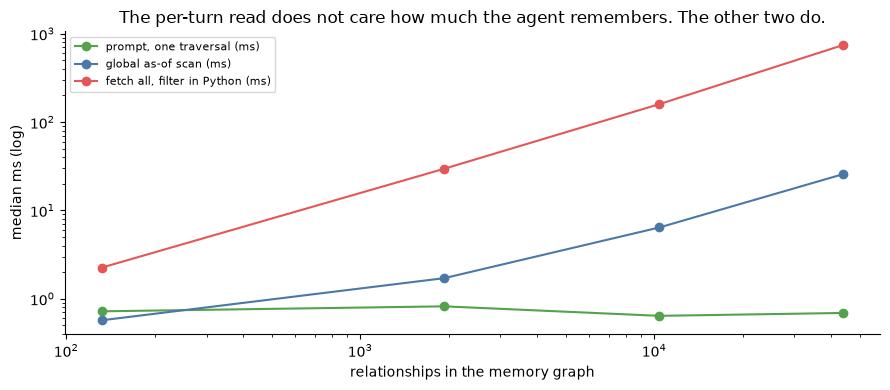

filler removed (18001 nodes); back to {'nodes': 171, 'relationships': 132, 'by_label': {'MemTool': 25, 'MemTask': 20, 'MemProject': 18, 'MemSkill': 17, 'MemArtifact': 15, 'MemEvent': 14, 'MemConstraint': 12, 'MemPerson': 10, 'MemTopic': 10, 'MemOrganization': 9, 'MemGoal': 8, 'MemPlace': 7, 'MemEpisode': 5, 'MemUser': 1}}


In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for column, colour in [("prompt, one traversal (ms)", "#54A24B"),
                       ("global as-of scan (ms)", "#4C78A8"),
                       ("fetch all, filter in Python (ms)", "#E45756")]:
    ax.plot(scaling.index, scaling[column], marker="o", color=colour, label=column)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("relationships in the memory graph"); ax.set_ylabel("median ms (log)")
ax.set_title("The per-turn read does not care how much the agent remembers. The other two do.")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

records, _, _ = driver.execute_query(
    "MATCH (n:MemFiller) WITH n LIMIT 200000 DETACH DELETE n RETURN count(*) AS n")
print(f"filler removed ({records[0]['n']} nodes); back to {mn.memory_counts(driver)}")

The anchored read is flat. It starts from a unique-constraint index seek on one node and expands that node's
relationships, so its cost is a function of how many facts *this user* has, not of how many facts exist.
That is the query on the hot path, and it is the one that scales.

The other two grow linearly, and the client-side one grows fastest because it pays for serialisation and a
network transfer of the whole graph before the first comparison. It is already the slowest option at the
smallest size measured here, and by the largest it is well past any plausible per-turn budget. If your memory
layer's read path is "load the store, filter in the application", the ceiling is a few thousand facts and it
arrives without warning — nothing errors, the assistant just gets slower.

The global as-of scan is the honest limitation of encoding A. Point-in-time questions that are not anchored to
a subject — *"what did we believe about anything on 1 March"*, *"which facts became false last quarter"* —
touch every relationship, and no single index helps because the predicate spans sixteen relationship types.
Options, in the order you would try them: anchor the query to a subject (usually possible), index the two or
three relationship types that actually get asked about, or accept that cross-cutting temporal analytics is a
batch job and not a request-path query.

### The rest of the list, without measurements

- **`superseded_at IS NULL` is unindexable.** Measured above. Sentinel timestamps fix it and cost a
  consistency invariant.
- **One index per relationship type.** Sixteen relations means sixteen index definitions to maintain, and a
  new relation silently gets none.
- **Supersession is a write-time decision that cannot be revisited cheaply.** If a `replaces` edge turns out
  to be wrong — and §4 wrote two that are — un-superseding means finding every fact closed by that
  `superseded_by` id and reopening it. Nothing here does that. It is a fact-level operation, and it is the
  strongest argument for reification that this notebook found.
- **Community edition is one database.** Namespacing works for label-scoped queries and nothing else. Multi-
  tenant memory on Community means every query carries a tenant predicate, which is exactly the kind of
  invariant that gets forgotten once.
- **No embedding path.** Structural retrieval answers "what is currently true about this node". It does not
  answer "what did the user say about latency in April", which needs the turn text, a vector index, and
  notebook 02's machinery pointed at episodes instead of documents.

---

## 7. Giving the database back

The memory namespace coexisted with notebook 02's business-news graph for the whole notebook, on one Neo4j
Community instance with one database. Coexistence held because every query on both sides is label-scoped —
and it would not have held for a database-wide aggregate, which is why the namespace comes out again rather
than being left as a surprise for whoever runs notebook 02 next.

`kgx.memory_neo4j.teardown` removes exactly what this notebook wrote: every `:__Memory__` node (which takes
its relationships with it), every index whose name starts with `mem`, and every constraint on a `Mem` label.

In [37]:
FINAL_MEMORY = mn.memory_counts(driver)
records, _, _ = driver.execute_query(
    "MATCH (:__Memory__)-[r]->(:__Memory__) WHERE r.relation IS NOT NULL "
    "RETURN count(*) AS facts, count(r.superseded_at) AS superseded")
FINAL_FACTS = dict(records[0])
print("memory namespace before teardown:", FINAL_MEMORY)
print("facts:", FINAL_FACTS)
result = mn.teardown(driver)
print(f"\ndeleted {result['nodes_deleted']} nodes")
print(f"dropped indexes    : {result['indexes_dropped']}")
print(f"dropped constraints: {len(result['constraints_dropped'])}")

memory namespace before teardown: {'nodes': 171, 'relationships': 132, 'by_label': {'MemTool': 25, 'MemTask': 20, 'MemProject': 18, 'MemSkill': 17, 'MemArtifact': 15, 'MemEvent': 14, 'MemConstraint': 12, 'MemPerson': 10, 'MemTopic': 10, 'MemOrganization': 9, 'MemGoal': 8, 'MemPlace': 7, 'MemEpisode': 5, 'MemUser': 1}}
facts: {'facts': 132, 'superseded': 9}



deleted 171 nodes
dropped indexes    : ['mem_entity_ft', 'mem_entity_norm', 'mem_probe_open', 'mem_probe_validfrom', 'mem_probe_window']
dropped constraints: 16


In [38]:
final = counts(driver)
records, _, _ = driver.execute_query(
    "SHOW INDEXES YIELD name, type WHERE type IN ['VECTOR','FULLTEXT'] RETURN name ORDER BY name")
final_indexes = [r["name"] for r in records]

checks = [
    ("total nodes", BASELINE["nodes"], final["nodes"]),
    ("total relationships", BASELINE["relationships"], final["relationships"]),
    ("labels", BASELINE["by_label"], final["by_label"]),
    ("relationship types", BASELINE["by_type"], final["by_type"]),
    ("search indexes", BASELINE_INDEXES, final_indexes),
]
for name, expected, got in checks:
    status = "OK  " if expected == got else "DIFF"
    print(f"  {status} {name}")
    if expected != got:
        print(f"       expected {expected}")
        print(f"       got      {got}")

assert all(e == g for _, e, g in checks), "notebook 02's graph was not restored"
print(f"\nnotebook 02's graph is exactly as it was: {final['nodes']} nodes, "
      f"{final['relationships']} relationships, {len(final_indexes)} search indexes.")

# And it still answers. A fulltext hit that returns only business-news entities is the
# proof that the memory graph never joined :__Entity__ or its indexes.
records, _, _ = driver.execute_query(
    "CALL db.index.fulltext.queryNodes('entity_ft', 'Northwind') YIELD node, score "
    "RETURN labels(node) AS labels, node.name AS name ORDER BY score DESC LIMIT 3")
for r in records:
    print(f"  entity_ft hit: {r['name']}  {r['labels']}")

  OK   total nodes
  OK   total relationships
  OK   labels
  OK   relationship types
  OK   search indexes

notebook 02's graph is exactly as it was: 119 nodes, 241 relationships, 4 search indexes.
  entity_ft hit: Northwind Logistics Inc  ['Company', '__Entity__']


## What this bought

The business-news graph in notebook 02 became queryable. The memory graph needed three things that a
finished-graph loader does not have, and each of them turned out to be a modelling decision rather than a
detail:

**Validity has to live on the edge, and the edge has to keep its type.** Bi-temporal properties on the
relationship keep the per-turn read at one hop and — measured in §2 — keep the relationship type working as a
free index, which reified fact nodes give up. The trade is real in both directions: anything that needs to
*point at a fact* is inexpressible on encoding A, and `(r)-[:X]->(n)` is a Cypher type error rather than a
style choice.

**Resolution has to run against the database.** Candidate generation in Cypher, scoring unchanged, two passes.
It agreed with batch resolution on every mention in the held-out session while scoring fewer than one
candidate per mention in pass 1, against a registry that has to hold and re-embed every known entity before
it can block at all.

**The write path is where correctness lives.** Replay detection, supersede, corroborate, insert — in that
order, with `replaces` facts first. The order is not a detail: the shipped `mn.assert_fact` puts corroboration
ahead of supersession, and §4 had to reorder it because an already-believed value short-circuited the one
supersession the corpus exists to demonstrate. The supersession rule for `alternatives` relations is a graph
pattern over `REPLACES` edges the extractor produced from sentences the user said, which is why it needs no
alternatives table and why every supersession under it can be explained. `single` relations close the old
value on policy instead, with no evidence behind them.

Two negative results are worth more than any of them. The first: **the store layer is only as good as the edge
it is waiting for.** Session 5 states a switch from Python to Go three times in plain language, GLiNER2.5 records it
as two skills, and the temporal layer correctly does nothing. Escalating that one session to Claude Haiku
recovers the `replaces` edge and the supersession fires through the identical Cypher — at the cost, in the
single sampled pass run here, of twelve ontology violations and two spurious supersessions. There is no
version of this where the storage layer rescues a recall failure upstream, and escalating a whole episode to
fix one edge pays for the whole episode.

The second: **grouping the finished graph by name finds thirty names that resolve to more than one node.** Type-
scoped entity resolution never compares `Jenkins` the `topic` with `Jenkins` the `place`, so the memory holds
four Jenkinses, each with its own facts and its own supersession history. Nothing in the temporal layer, the
schema, or the query plans matters as much as that, and none of it was visible until §4 asked the question.

In [39]:
summary = pd.DataFrame([
    {"stage": "sessions loaded in bulk (s1-s3)", "n": len(HISTORY)},
    {"stage": "sessions written back incrementally", "n": len(HELD_OUT)},
    {"stage": "facts in the graph at the end", "n": FINAL_FACTS["facts"]},
    {"stage": "of those, superseded", "n": FINAL_FACTS["superseded"]},
    {"stage": "gold contradictions recovered", "n": 2},
    {"stage": "mentions resolved against the live graph", "n": len(s4_res["assigned"])
                                                               + len(s5_res["assigned"])},
]).set_index("stage")
display(summary)

print(f"LLM spend on this run: ${llm.total_cost_usd:.4f} "
      f"({llm.n_calls} live calls, {llm.n_cached} from cache)")
print(f"cost of the cached responses when first paid for: ${llm.cached_cost_usd:.4f}")
print(f"cache: {len(list(llm.cache_dir.glob('*.json')))} responses in {llm.cache_dir}")

,n
stage,
sessions loaded in bulk (s1-s3),3
sessions written back incrementally,2
facts in the graph at the end,132
"of those, superseded",9
gold contradictions recovered,2
mentions resolved against the live graph,165


LLM spend on this run: $0.0000 (0 live calls, 5 from cache)
cost of the cached responses when first paid for: $0.0272
cache: 105 responses in /Users/lyonwj/github/johnymontana/extraction-sandbox/output/llm_cache


## Where to take it

**Un-supersede.** §4 wrote two supersessions caused by a wrong `replaces` edge, and there is no way to undo
one. The operation is "find every fact closed by this `superseded_by` id and reopen it", which is a query
about facts, not about entities — and on encoding A a fact has no identity you can point at. This is the
concrete case for reifying, and the right design is probably hybrid: relationship properties for the hot read,
`MemFact` nodes materialised only for facts under dispute.

**The review queue.** `TemporalGraph.candidates` collects competing assertions no rule was confident enough to
resolve, and nothing here surfaces them in the database. A `(:MemConflict)` node per unresolved pair, with the
evidence attached, is a day of work and turns the failure in §4 from invisible into a list someone can look at.

**An adjudicator instead of a full escalation.** The blunt escalation cost a dozen ontology violations in the
one pass measured here to recover one edge. Asking the LLM a single yes/no question — *does Go compete with
Python for this user?* — about each queued pair costs a fraction as much and writes nothing but a `REPLACES`
edge. Notebook 03's
escalation-trigger sweep is the method; the trigger here is "an `alternatives` relation gained a competing
value and no `replaces` edge explains it".

**Episode text and semantic retrieval.** No vector index was created, deliberately. A real assistant needs
both paths — structural for "what is true", semantic for "what did we discuss" — and joining them means
loading turns as nodes and pointing notebook 02's retrievers at them.

**Cross-type entity resolution.** Thirty names in the final graph are carried by more than one node, because
resolution only compares mentions of matching type and the extractor types the same string differently in
different windows. This is the largest source of error in the finished memory, larger than anything temporal,
and it is invisible until you group by name. A merge pass over same-key/different-type pairs — deterministic
where one type dominates, adjudicated where it does not — is probably the highest-value thing on this list.

**Multi-user.** Everything here is one user's memory in one namespace. Community edition's single database
makes tenancy a predicate on every query rather than a boundary the server enforces, which is a security
property, not a performance one.

**Scale the write path, not just the read.** §6 measured reads. The write path issues one query per fact and
was never profiled; at a hundred facts an episode that is fine, and at ten thousand it is the next thing to
break.

In [40]:
driver.close()
print("driver closed")

driver closed
